# HW4: Trade-flow signal on BTC-USDT trades

### Malank Goel (12350684)

**Goal.** Test whether short-horizon signed trade flow predicts forward returns, then evaluate a simple thresholded trading rule out of sample.

**Plan.**
1) Load data and split train/test per exchange (40/60).
2) Build flow $F_i(\tau)$ and forward return $r_i(T)$.
3) Fit $\beta$ on train, calibrate threshold $j$ to a target participation rate, then trade on test.
4) Compare easy round-trip vs cumulative-inventory P&L with/without costs.
5) Diagnose fit quality and volatility conditioning; run participation robustness.

**Subjective choices (affect results).**
- $\tau=1$ minute and $T=5$ minutes (short-horizon focus; aligns with HW guidance and keeps microstructure effects visible).
- Baseline participation target 5% for $j$ (per HW suggestion), plus 2/10/20% sensitivity later.
- Costs = 1 bp per execution leg; bucket = 5 minutes; size_mult = 1.0.


In [1]:
import warnings
warnings.filterwarnings("ignore")


In [2]:
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 120)

data_path = Path("/Users/malank/Documents/Crypto/BTC-USDT_trades.parquet")

pf = pq.ParquetFile(data_path)
meta = {
    "num_rows": pf.metadata.num_rows,
    "num_row_groups": pf.metadata.num_row_groups,
    "num_columns": pf.metadata.num_columns,
    "created_by": pf.metadata.created_by
}

schema = pf.schema_arrow
cols = schema.names
schema_out = {"columns": cols, "schema": str(schema)}

df = pd.read_parquet(data_path, engine="pyarrow")

meta, schema_out, df.shape, df.head(5)

({'num_rows': 127774941,
  'num_row_groups': 3,
  'num_columns': 6,
  'created_by': 'fastparquet-python version 2024.11.0 (build 0)'},
 {'columns': ['index', 'ts', 'side', 'qty', 'trade_price', 'Exchange'],
  'schema': 'index: int64\nts: timestamp[ns]\nside: string\nqty: double\ntrade_price: double\nExchange: string\n-- schema metadata --\npandas: \'{"column_indexes": [{"field_name": null, "metadata": null, "name\' + 896'},
 (127774941, 5),
                                  ts side       qty  trade_price Exchange
 index                                                                   
 846   2025-05-22 00:00:00.059739309    B  0.000080     109646.0      OKX
 958   2025-05-22 00:00:00.172964441    B  0.000181     109648.0      OKX
 959   2025-05-22 00:00:00.176589875    B  0.000010     109650.0      OKX
 960   2025-05-22 00:00:00.176589875    B  0.003134     109654.4      OKX
 968   2025-05-22 00:00:00.179674740    B  0.000015     109655.3      OKX)

## Data split (per exchange)

Sort each exchange chronologically (stable sort with a deterministic tie-breaker) and split **first 40% train / last 60% test**. This avoids leakage across exchanges and enforces the assignment's per-exchange split requirement.


In [3]:
ex_col = "Exchange" if "Exchange" in df.columns else ("exchange" if "exchange" in df.columns else None)
ts_col = "ts" if "ts" in df.columns else None
idx_col = "index" if "index" in df.columns else None

order_cols = [c for c in [ex_col, ts_col, idx_col] if c is not None]
df = df.sort_values(order_cols, kind="mergesort")

g = df.groupby(ex_col, sort=False)
pos = g.cumcount()
n = g[ts_col].transform("size")
cut = (n * 0.4).astype(np.int64)

df["is_train"] = pos < cut
df_train = df[df["is_train"]].copy()
df_test = df[~df["is_train"]].copy()

train_counts = df_train[ex_col].value_counts().sort_index()
test_counts = df_test[ex_col].value_counts().sort_index()

df_train.shape, df_test.shape, train_counts.to_dict(), test_counts.to_dict()
df_train.head(5), df_test.head(5)

(                                 ts side      qty  trade_price Exchange  is_train
 index                                                                            
 68736 2025-05-01 00:00:00.080617926    A  0.00067     94172.00  BINANCE      True
 68738 2025-05-01 00:00:00.081665583    A  0.00011     94172.00  BINANCE      True
 68739 2025-05-01 00:00:00.081665583    A  0.00095     94172.00  BINANCE      True
 68786 2025-05-01 00:00:00.221696775    B  0.00022     94172.01  BINANCE      True
 68834 2025-05-01 00:00:00.468659922    A  0.00012     94172.00  BINANCE      True,
                                    ts side      qty  trade_price Exchange  is_train
 index                                                                              
 3678140 2025-05-15 02:59:37.535264097    A  0.00097    103047.62  BINANCE     False
 3678177 2025-05-15 02:59:38.149326291    A  0.00097    103047.62  BINANCE     False
 3678179 2025-05-15 02:59:38.193276825    A  0.00097    103047.62  BINANCE    

## Signal construction functions (collapse-ready)

Functions live here so the grader can collapse them. For a chosen exchange:
- Create a deterministic `row_id` to break timestamp ties.
- Compute $F_i(\tau)$ as signed quantity over $(t_i-\tau, t_i)$ with `closed="left"`, so the trade at $t_i$ and any trades at the same timestamp are excluded.
- Compute $r_i(T)=\log\{p(t_i+T)/p(t_i)\}$ where $p(t_i+T)$ is the first trade price at or after $t_i+T$.

These choices align with the timing rules in the HW prompt.


In [4]:
import numpy as np
import pandas as pd

def prepare_exchange_df(df, exchange, ex_col="Exchange"):
    d = df[df[ex_col] == exchange].copy()
    d["row_id"] = np.arange(len(d), dtype=np.int64)
    d = d.sort_values(["ts", "row_id"], kind="mergesort").reset_index(drop=True)
    return d

def compute_flow_and_return(d, tau_s=1, T_s=5):
    tau = pd.Timedelta(seconds=float(tau_s))
    T = pd.Timedelta(seconds=float(T_s))

    side = d["side"].astype(str).values
    qty = d["qty"].astype(float).values
    sign = np.where(side == "B", 1.0, -1.0)
    signed_qty = sign * qty

    s = pd.Series(signed_qty, index=d["ts"])
    F_tau = s.rolling(tau, closed="left").sum()
    F_tau = F_tau.fillna(0.0).to_numpy()

    ts_vals = d["ts"].values.astype("datetime64[ns]")
    future_times = (d["ts"] + T).values.astype("datetime64[ns]")
    future_idx = np.searchsorted(ts_vals, future_times, side="left")

    p0 = d["trade_price"].astype(float).values
    pT = np.full(len(d), np.nan, dtype=float)
    ok = future_idx < len(d)
    pT[ok] = p0[future_idx[ok]]

    r_T = np.log(pT / p0)

    d = d.copy()
    d["F_tau"] = F_tau
    d["r_T"] = r_T
    d["future_idx"] = future_idx
    d["future_time"] = d["ts"] + T
    return d

def fit_beta_and_threshold(d, target_participation=0.05):
    train_mask = d["is_train"].astype(bool).values
    train_end_ts = d.loc[train_mask, "ts"].max()

    valid_train = (
        train_mask
        & np.isfinite(d["F_tau"].values)
        & np.isfinite(d["r_T"].values)
        & (d["future_time"].values <= train_end_ts.to_datetime64())
    )

    F = d.loc[valid_train, "F_tau"].astype(float).values
    r = d.loc[valid_train, "r_T"].astype(float).values

    denom = float(np.dot(F, F))
    beta = float(np.dot(F, r) / denom) if denom > 0 else np.nan

    d = d.copy()
    d["r_hat"] = beta * d["F_tau"].astype(float).values

    q = 1.0 - float(target_participation)
    abs_rhat_train = np.abs(d.loc[valid_train, "r_hat"].astype(float).values)
    j = float(np.quantile(abs_rhat_train, q)) if len(abs_rhat_train) > 0 else np.nan

    return d, beta, j, valid_train

## Fit $\beta$ and calibrate threshold $j$ (per exchange)

On the training set only, fit the through-origin regression $r_i(T)=\beta F_i(\tau)$ and predict $\hat r_i$ for all trades. Then set the trading threshold $j$ to hit a **target participation rate** on the training sample (baseline 5%), i.e., $j$ is the $(1-\pi)$ quantile of $|\hat r_i|$ on eligible training observations.

This makes the only policy knob the participation target (as suggested by the HW).


In [5]:
tau_s = 60
T_s = 300
target_participation = 0.05

ex_col = "Exchange" if "Exchange" in df.columns else ("exchange" if "exchange" in df.columns else None)
exchanges = sorted(df[ex_col].dropna().unique().tolist())

exchange_dfs = {}
rows = []

for ex in exchanges:
    d = prepare_exchange_df(df, ex, ex_col=ex_col)
    d = compute_flow_and_return(d, tau_s=tau_s, T_s=T_s)
    d, beta, j, valid_train = fit_beta_and_threshold(d, target_participation=target_participation)

    test_mask = (~d["is_train"].astype(bool).values) & np.isfinite(d["r_T"].values)
    train_part = float((np.abs(d.loc[valid_train, "r_hat"].astype(float).values) > j).mean()) if np.isfinite(j) else np.nan
    test_part = float((np.abs(d.loc[test_mask, "r_hat"].astype(float).values) > j).mean()) if np.isfinite(j) else np.nan

    r_T_nan_count = int(pd.isna(d["r_T"]).sum())
    F_tau_nan_count = int(pd.isna(d["F_tau"]).sum())

    exchange_dfs[ex] = d

    rows.append({
        "exchange": ex,
        "n_rows": int(len(d)),
        "n_train_used": int(valid_train.sum()),
        "n_test_with_return": int(test_mask.sum()),
        "beta": beta,
        "j_threshold": j,
        "train_participation_rate": train_part,
        "test_participation_rate": test_part,
        "F_tau_nan_count": F_tau_nan_count,
        "r_T_nan_count": r_T_nan_count
    })

results = pd.DataFrame(rows).sort_values("exchange").reset_index(drop=True)
results

,exchange,n_rows,n_train_used,n_test_with_return,beta,j_threshold,train_participation_rate,test_participation_rate,F_tau_nan_count,r_T_nan_count
0,BINANCE,108853357,43535666,65309370,1.600161e-06,0.000077,0.050000,0.044905,0,2645
1,BITSTAMP,6862,2743,4116,-1.549243e-03,0.000346,0.050310,0.041788,0,2
2,COINBASE,453988,181477,272391,2.049484e-04,0.000176,0.050001,0.057333,0,2
3,DERIBIT,61973,24771,37182,7.644834e-08,0.001061,0.050018,0.018665,0,2
4,GATE_IO,4940305,1974340,2964080,5.055272e-06,0.000049,0.050000,0.114494,0,103
5,OKX,13458456,5382758,8074887,1.020142e-05,0.000381,0.049998,0.036389,0,187


## Training diagnostics

Compute quick checks on the training fit (per exchange): correlation between $F$ and $r$, through-origin $R^2$, and basic moments. These help flag weak or unstable fits before moving to P&L.


In [6]:
diag_rows = []

for ex, d in exchange_dfs.items():
    train_mask = d["is_train"].astype(bool).values
    train_end_ts = d.loc[train_mask, "ts"].max()
    valid_train = (
        train_mask
        & np.isfinite(d["F_tau"].values)
        & np.isfinite(d["r_T"].values)
        & (d["future_time"].values <= train_end_ts.to_datetime64())
    )

    F = d.loc[valid_train, "F_tau"].astype(float).values
    r = d.loc[valid_train, "r_T"].astype(float).values
    rhat = d.loc[valid_train, "r_hat"].astype(float).values

    corr = float(np.corrcoef(F, r)[0, 1]) if len(F) > 1 else np.nan
    sst = float(np.dot(r, r))
    sse = float(np.dot(r - rhat, r - rhat))
    r2_origin = 1.0 - (sse / sst) if sst > 0 else np.nan

    diag_rows.append({
        "exchange": ex,
        "corr_F_r_train": corr,
        "r2_through_origin_train": r2_origin,
        "F_tau_mean_train": float(np.mean(F)) if len(F) > 0 else np.nan,
        "F_tau_std_train": float(np.std(F, ddof=1)) if len(F) > 1 else np.nan,
        "r_T_mean_train": float(np.mean(r)) if len(r) > 0 else np.nan,
        "r_T_std_train": float(np.std(r, ddof=1)) if len(r) > 1 else np.nan
    })

diags = pd.DataFrame(diag_rows).sort_values("exchange").reset_index(drop=True)
results = results.merge(diags, on="exchange", how="left")
results

,exchange,n_rows,n_train_used,n_test_with_return,beta,j_threshold,train_participation_rate,test_participation_rate,F_tau_nan_count,r_T_nan_count,corr_F_r_train,r2_through_origin_train,F_tau_mean_train,F_tau_std_train,r_T_mean_train,r_T_std_train
0,BINANCE,108853357,43535666,65309370,1.600161e-06,0.000077,0.050000,0.044905,0,2645,0.028115,0.000896,2.191003,28.878504,0.000039,0.001548
1,BITSTAMP,6862,2743,4116,-1.549243e-03,0.000346,0.050310,0.041788,0,2,-0.091340,0.008351,-0.000373,0.126346,0.000089,0.002140
2,COINBASE,453988,181477,272391,2.049484e-04,0.000176,0.050001,0.057333,0,2,0.079043,0.006525,0.021502,0.677885,0.000104,0.001718
3,DERIBIT,61973,24771,37182,7.644834e-08,0.001061,0.050018,0.018665,0,2,0.173875,0.033744,438.964475,5760.315362,0.000405,0.002370
4,GATE_IO,4940305,1974340,2964080,5.055272e-06,0.000049,0.050000,0.114494,0,103,0.013361,0.000274,0.406493,5.006416,0.000062,0.001532
5,OKX,13458456,5382758,8074887,1.020142e-05,0.000381,0.049998,0.036389,0,187,0.140481,0.020730,1.824573,23.384231,0.000088,0.001660


## Implementation checks (timing + stability)

Timing rules are satisfied in the checks summary: `future_ts_violation_frac` is 0.0 for every exchange and `same_ts_flow_max_abs_diff` is effectively 0 (on the order of 1e-16). That confirms the flow window excludes same-timestamp trades and the forward return uses the first trade at or after $t_i+T$.

Stability is weak. The split-sample check shows $\beta$ sign flips for every exchange except COINBASE, and the ratio of second-half to first-half magnitude ranges from 0.28 (COINBASE) up to 9.21 (OKX). This points to regime dependence even within the training window.


In [7]:
tau = pd.Timedelta(seconds=float(tau_s)) if "tau_s" in globals() else pd.Timedelta(seconds=1)
T = pd.Timedelta(seconds=float(T_s)) if "T_s" in globals() else pd.Timedelta(seconds=5)

def _beta_through_origin(F, r):
    denom = float(np.dot(F, F))
    return float(np.dot(F, r) / denom) if denom > 0 else np.nan

rows = []

for ex, d in exchange_dfs.items():
    ex_out = {"exchange": ex}

    ts_arr = d["ts"].values.astype("datetime64[ns]")
    n = len(ts_arr)

    side_arr = d["side"].astype(str).values
    qty_arr = d["qty"].astype(float).values
    sign_arr = np.where(side_arr == "B", 1.0, -1.0)
    signed_qty = sign_arr * qty_arr

    F_tau_arr = d["F_tau"].astype(float).values
    r_T_arr = d["r_T"].astype(float).values
    future_idx = d["future_idx"].values
    future_time = d["future_time"].values.astype("datetime64[ns]")

    train_mask = d["is_train"].astype(bool).values
    train_n = int(train_mask.sum())
    train_end_ts = d.loc[train_mask, "ts"].max()

    valid_train = (
        train_mask
        & np.isfinite(F_tau_arr)
        & np.isfinite(r_T_arr)
        & (future_time <= train_end_ts.to_datetime64())
    )

    valid_test = (
        (~train_mask)
        & np.isfinite(F_tau_arr)
        & np.isfinite(r_T_arr)
    )

    if n > 0:
        changes = np.empty(n, dtype=bool)
        changes[0] = True
        changes[1:] = ts_arr[1:] != ts_arr[:-1]
        uniq = int(changes.sum())
        ex_out["ts_unique_frac"] = float(uniq / n)

        run_starts = np.flatnonzero(changes)
        run_ends = np.r_[run_starts[1:], n]
        run_lens = run_ends - run_starts
        max_run = int(run_lens.max()) if len(run_lens) > 0 else 0
        ex_out["max_trades_same_ts"] = max_run

        tie_pos = np.flatnonzero(run_lens > 1)
        if len(tie_pos) > 0:
            k = int(tie_pos[0])
            a = int(run_starts[k])
            b = int(run_ends[k])
            t0 = ts_arr[a]
            left = int(np.searchsorted(ts_arr, t0 - tau.to_timedelta64(), side="left"))
            right = int(np.searchsorted(ts_arr, t0, side="left"))
            flow_manual = float(signed_qty[left:right].sum())
            flow_vals = F_tau_arr[a:b]
            ex_out["same_ts_flow_max_abs_diff"] = float(np.max(np.abs(flow_vals - flow_manual))) if len(flow_vals) > 0 else np.nan
        else:
            ex_out["same_ts_flow_max_abs_diff"] = np.nan
    else:
        ex_out["ts_unique_frac"] = np.nan
        ex_out["max_trades_same_ts"] = 0
        ex_out["same_ts_flow_max_abs_diff"] = np.nan

    ok = future_idx < n
    if ok.any():
        future_ts = ts_arr[future_idx[ok]]
        ft = future_time[ok]
        ex_out["future_ts_violation_frac"] = float((future_ts < ft).mean())
    else:
        ex_out["future_ts_violation_frac"] = np.nan

    ex_out["F_tau_nan_count"] = int(np.isnan(F_tau_arr).sum())
    ex_out["r_T_nan_count"] = int(np.isnan(r_T_arr).sum())

    if valid_train.any():
        F = F_tau_arr[valid_train]
        r = r_T_arr[valid_train]
        ex_out["corr_F_r_train"] = float(np.corrcoef(F, r)[0, 1]) if len(F) > 1 else np.nan
        rhat = d.loc[valid_train, "r_hat"].astype(float).values
        sst = float(np.dot(r, r))
        sse = float(np.dot(r - rhat, r - rhat))
        ex_out["r2_through_origin_train"] = 1.0 - (sse / sst) if sst > 0 else np.nan
        ex_out["F_tau_mean_train"] = float(np.mean(F))
        ex_out["F_tau_std_train"] = float(np.std(F, ddof=1)) if len(F) > 1 else np.nan
        ex_out["r_T_mean_train"] = float(np.mean(r))
        ex_out["r_T_std_train"] = float(np.std(r, ddof=1)) if len(r) > 1 else np.nan
    else:
        ex_out["corr_F_r_train"] = np.nan
        ex_out["r2_through_origin_train"] = np.nan
        ex_out["F_tau_mean_train"] = np.nan
        ex_out["F_tau_std_train"] = np.nan
        ex_out["r_T_mean_train"] = np.nan
        ex_out["r_T_std_train"] = np.nan

    if valid_train.any():
        r_buy = r_T_arr[valid_train & (side_arr == "B")]
        r_sell = r_T_arr[valid_train & (side_arr != "B")]
        m_buy = float(np.mean(r_buy)) if len(r_buy) > 0 else np.nan
        m_sell = float(np.mean(r_sell)) if len(r_sell) > 0 else np.nan
        ex_out["mean_r_T_B_train"] = m_buy
        ex_out["mean_r_T_notB_train"] = m_sell
        ex_out["mean_r_T_diff_B_minus_notB_train"] = (m_buy - m_sell) if np.isfinite(m_buy) and np.isfinite(m_sell) else np.nan
    else:
        ex_out["mean_r_T_B_train"] = np.nan
        ex_out["mean_r_T_notB_train"] = np.nan
        ex_out["mean_r_T_diff_B_minus_notB_train"] = np.nan

    if train_n > 0:
        split_pos = train_n // 2
        pos = np.arange(n, dtype=np.int64)
        first_half = valid_train & (pos < split_pos)
        second_half = valid_train & (pos >= split_pos)

        F1 = F_tau_arr[first_half]
        r1 = r_T_arr[first_half]
        F2 = F_tau_arr[second_half]
        r2 = r_T_arr[second_half]

        beta1 = _beta_through_origin(F1, r1) if len(F1) > 0 else np.nan
        beta2 = _beta_through_origin(F2, r2) if len(F2) > 0 else np.nan

        ex_out["beta_train_first_half"] = beta1
        ex_out["beta_train_second_half"] = beta2
        ex_out["beta_sign_flip"] = bool(np.sign(beta1) != np.sign(beta2)) if np.isfinite(beta1) and np.isfinite(beta2) and beta1 != 0 and beta2 != 0 else False
        ex_out["beta_ratio_abs_second_over_first"] = float(np.abs(beta2) / np.abs(beta1)) if np.isfinite(beta1) and np.isfinite(beta2) and beta1 != 0 else np.nan
    else:
        ex_out["beta_train_first_half"] = np.nan
        ex_out["beta_train_second_half"] = np.nan
        ex_out["beta_sign_flip"] = False
        ex_out["beta_ratio_abs_second_over_first"] = np.nan

    qty_train = qty_arr[:train_n] if train_n > 0 else qty_arr[:0]
    if len(qty_train) > 0:
        k = int(0.999 * (len(qty_train) - 1))
        q_cut = float(np.partition(qty_train, k)[k])
        vol_total = float(np.sum(qty_train))
        vol_tail = float(np.sum(qty_train[qty_train >= q_cut]))
        ex_out["qty_p999_train"] = q_cut
        ex_out["qty_top_0p1pct_volume_share_train"] = (vol_tail / vol_total) if vol_total > 0 else np.nan
    else:
        ex_out["qty_p999_train"] = np.nan
        ex_out["qty_top_0p1pct_volume_share_train"] = np.nan

    ex_out["n_rows"] = int(n)
    ex_out["n_train_used"] = int(valid_train.sum())
    ex_out["n_test_with_return"] = int(valid_test.sum())

    rows.append(ex_out)

checks_df = pd.DataFrame(rows).sort_values("exchange").reset_index(drop=True)
checks_df


,exchange,ts_unique_frac,max_trades_same_ts,same_ts_flow_max_abs_diff,future_ts_violation_frac,F_tau_nan_count,r_T_nan_count,corr_F_r_train,r2_through_origin_train,F_tau_mean_train,F_tau_std_train,r_T_mean_train,r_T_std_train,mean_r_T_B_train,mean_r_T_notB_train,mean_r_T_diff_B_minus_notB_train,beta_train_first_half,beta_train_second_half,beta_sign_flip,beta_ratio_abs_second_over_first,qty_p999_train,qty_top_0p1pct_volume_share_train,n_rows,n_train_used,n_test_with_return
0,BINANCE,0.142191,688,0.000000e+00,0.0,0,2645,0.028115,0.000896,2.191003,28.878504,0.000039,0.001548,0.000164,-0.000083,0.000247,3.827419e-06,-1.532698e-06,True,0.400452,0.640240,0.168995,108853357,43535666,65309370
1,BITSTAMP,0.987467,3,0.000000e+00,0.0,0,2,-0.091340,0.008351,-0.000373,0.126346,0.000089,0.002140,0.000055,0.000118,-0.000063,1.082293e-03,-2.016832e-03,True,1.863481,0.618967,0.081011,6862,2743,4116
2,COINBASE,0.696697,39,0.000000e+00,0.0,0,2,0.079043,0.006525,0.021502,0.677885,0.000104,0.001718,0.000216,0.000006,0.000210,2.429511e-04,6.756425e-05,False,0.278098,0.215986,0.040999,453988,181477,272391
3,DERIBIT,0.922950,14,0.000000e+00,0.0,0,2,0.173875,0.033744,438.964475,5760.315362,0.000405,0.002370,0.000451,0.000365,0.000085,-2.690898e-08,9.849878e-08,True,3.660442,4844.000000,0.037996,61973,24771,37182
4,GATE_IO,0.981510,25,5.551115e-17,0.0,0,103,0.013361,0.000274,0.406493,5.006416,0.000062,0.001532,0.000161,-0.000054,0.000215,-3.008216e-06,1.747100e-05,True,5.807759,4.995280,0.295308,4940305,1974340,2964080
5,OKX,0.513823,598,1.734723e-18,0.0,0,187,0.140481,0.020730,1.824573,23.384231,0.000088,0.001660,0.000163,0.000005,0.000158,-1.922030e-06,1.771094e-05,True,9.214705,1.067124,0.131574,13458456,5382758,8074887


## Implementation considerations

- **Latency and queue priority**: the signal is defined on printed trades, so real execution would suffer from latency and adverse selection; this is a backtest on prints, not a live order-book simulation.
- **Fee model**: a simple bps cost per leg is used; actual fees/spreads are venue- and tier-dependent, and rebates/fees could materially change net P&L.
- **Inventory risk**: the cumulative ledger P&L is sensitive to inventory accumulation; without explicit inventory limits, results can be dominated by mark-to-market drift.
- **Non-stationarity**: the flow-return relationship can change with regime (volatility, liquidity, participant mix), so a rolling or re-estimated $\\beta$ is a realistic extension.


In [8]:
if "checks_df" in globals():
    cols = [
        "exchange",
        "future_ts_violation_frac",
        "same_ts_flow_max_abs_diff",
        "beta_sign_flip",
        "beta_ratio_abs_second_over_first"
    ]
    checks_summary = checks_df[cols].copy()
    print(checks_summary)
else:
    print("checks_df not found. Run the implementation checks cell first.")


   exchange  future_ts_violation_frac  same_ts_flow_max_abs_diff  beta_sign_flip  beta_ratio_abs_second_over_first
0   BINANCE                       0.0               0.000000e+00            True                          0.400452
1  BITSTAMP                       0.0               0.000000e+00            True                          1.863481
2  COINBASE                       0.0               0.000000e+00           False                          0.278098
3   DERIBIT                       0.0               0.000000e+00            True                          3.660442
4   GATE_IO                       0.0               5.551115e-17            True                          5.807759
5       OKX                       0.0               1.734723e-18            True                          9.214705


## Trading rule and P&L implementations

**Rule.** Trade when $|\hat r_i|>j$; direction is the sign of $\hat r_i$. Size is proportional to printed quantity (size_mult=1.0).

**P&L methods.**
1) **Easy round-trip**: enter at $t_i$ and exit at the first trade at/after $t_i+T$.
2) **Cumulative inventory ledger**: track inventory and cash; mark to the last price in each 5-minute bucket.

Both are reported with and without 1 bp costs.


In [9]:
cost_bps = 1.0
size_mult = 1.0
bucket = "5min"

j_map = results.set_index("exchange")["j_threshold"].to_dict()

def _bucket_grid_from_test(d, bucket="5min"):
    test_mask = (~d["is_train"].astype(bool).values)
    ts = pd.to_datetime(d.loc[test_mask, "ts"].values.astype("datetime64[ns]"))
    if len(ts) == 0:
        return pd.DatetimeIndex([], name="ts")
    t0 = ts.min().floor(bucket)
    t1 = ts.max().ceil(bucket)
    if t1 < t0:
        return pd.DatetimeIndex([], name="ts")
    return pd.date_range(t0, t1, freq=bucket, name="ts")

def _easy_events_for_exchange(d, j, size_mult=1.0):
    test_mask = (~d["is_train"].astype(bool).values) & np.isfinite(d["r_T"].values)
    rhat = d["r_hat"].astype(float).values
    take = test_mask & (np.abs(rhat) > float(j))

    if take.sum() == 0:
        return pd.DataFrame(columns=["entry_ts", "exit_ts", "p_entry", "p_exit", "qty", "direction"])

    entry_ts = pd.to_datetime(d.loc[take, "ts"].values.astype("datetime64[ns]"))
    p_entry  = d.loc[take, "trade_price"].astype(float).values
    qty      = d.loc[take, "qty"].astype(float).values * float(size_mult)
    direction = np.sign(rhat[take]).astype(float)

    idxT = d["future_idx"].values[take]
    exit_ts = pd.to_datetime(d["ts"].values.astype("datetime64[ns]")[idxT])
    p_exit  = d["trade_price"].astype(float).values[idxT]

    return pd.DataFrame({
        "entry_ts": entry_ts,
        "exit_ts": exit_ts,
        "p_entry": p_entry,
        "p_exit": p_exit,
        "qty": qty,
        "direction": direction
    }).sort_values("exit_ts", kind="mergesort")

def easy_roundtrip_bucketed(ev, grid, cost_bps=0.0, bucket="5min"):
    if len(grid) == 0:
        empty = pd.Series(dtype=float)
        return {
            "n_events": 0,
            "gross_pnl": 0.0,
            "net_pnl": 0.0,
            "cost_paid": 0.0,
            "equity_bucket": empty,
            "bucket_pnl": empty,
            "traded_notional_bucket": empty,
            "ret_bucket": empty
        }

    if len(ev) == 0:
        z = pd.Series(0.0, index=grid)
        return {
            "n_events": 0,
            "gross_pnl": 0.0,
            "net_pnl": 0.0,
            "cost_paid": 0.0,
            "equity_bucket": z.cumsum(),
            "bucket_pnl": z,
            "traded_notional_bucket": z,
            "ret_bucket": z
        }

    q = ev["qty"].astype(float).values
    dirn = ev["direction"].astype(float).values
    p0 = ev["p_entry"].astype(float).values
    p1 = ev["p_exit"].astype(float).values

    gross = dirn * (p1 - p0) * q
    cost_rate = float(cost_bps) / 10000.0
    costs = cost_rate * (np.abs(q) * (p0 + p1))
    net = gross - costs

    pnl = pd.Series(net, index=pd.to_datetime(ev["exit_ts"])).sort_index()
    bucket_pnl = pnl.resample(bucket).sum().reindex(grid, fill_value=0.0)

    entry_notional = pd.Series(np.abs(q) * p0, index=pd.to_datetime(ev["entry_ts"]))
    exit_notional  = pd.Series(np.abs(q) * p1, index=pd.to_datetime(ev["exit_ts"]))
    traded_notional_bucket = (
        entry_notional.resample(bucket).sum() + exit_notional.resample(bucket).sum()
    ).reindex(grid, fill_value=0.0)

    equity_bucket = bucket_pnl.cumsum()

    ret_bucket = pd.Series(0.0, index=grid)
    m = traded_notional_bucket.values > 0
    ret_bucket.iloc[m] = (bucket_pnl.iloc[m] / traded_notional_bucket.iloc[m]).values

    return {
        "n_events": int(len(ev)),
        "gross_pnl": float(np.sum(gross)),
        "net_pnl": float(np.sum(net)),
        "cost_paid": float(np.sum(costs)),
        "equity_bucket": equity_bucket,
        "bucket_pnl": bucket_pnl,
        "traded_notional_bucket": traded_notional_bucket,
        "ret_bucket": ret_bucket
    }

def _executions_for_exchange(d, j, size_mult=1.0):
    test_mask = (~d["is_train"].astype(bool).values) & np.isfinite(d["r_T"].values)
    rhat = d["r_hat"].astype(float).values
    take = test_mask & (np.abs(rhat) > float(j))

    if take.sum() == 0:
        return pd.DataFrame(columns=["ts", "price", "signed_qty", "abs_notional"])

    ts = pd.to_datetime(d.loc[take, "ts"].values.astype("datetime64[ns]"))
    price = d.loc[take, "trade_price"].astype(float).values
    qty = d.loc[take, "qty"].astype(float).values * float(size_mult)
    direction = np.sign(rhat[take]).astype(float)
    signed_qty = direction * qty

    ex = pd.DataFrame({
        "ts": ts,
        "price": price,
        "signed_qty": signed_qty,
        "abs_notional": np.abs(signed_qty) * price
    }).sort_values("ts", kind="mergesort")

    return ex

def cumulative_inventory_bucketed(d, ex, grid, cost_bps=0.0, bucket="5min"):
    if len(grid) == 0:
        empty = pd.Series(dtype=float)
        return {
            "n_exec": 0,
            "gross_pnl": 0.0,
            "net_pnl": 0.0,
            "cost_paid": 0.0,
            "end_inventory": 0.0,
            "equity_bucket": empty,
            "bucket_pnl": empty,
            "exec_notional_bucket": empty,
            "risk_base_bucket": empty,
            "ret_bucket": empty
        }

    test_mask = (~d["is_train"].astype(bool).values)
    trades = d.loc[test_mask, ["ts", "trade_price"]].copy()
    trades["ts"] = pd.to_datetime(trades["ts"].values.astype("datetime64[ns]"))
    trades = trades.sort_values("ts", kind="mergesort").drop_duplicates("ts").set_index("ts")
    price_bucket = (
        trades["trade_price"].astype(float)
        .resample(bucket).last().ffill()
        .reindex(grid, method="ffill")
        .ffill()
    )

    if len(ex) == 0:
        z = pd.Series(0.0, index=grid)
        return {
            "n_exec": 0,
            "gross_pnl": 0.0,
            "net_pnl": 0.0,
            "cost_paid": 0.0,
            "end_inventory": 0.0,
            "equity_bucket": z,
            "bucket_pnl": z,
            "exec_notional_bucket": z,
            "risk_base_bucket": z,
            "ret_bucket": z
        }

    cost_rate = float(cost_bps) / 10000.0
    ex = ex.copy().sort_values("ts", kind="mergesort").set_index("ts")

    signed_qty = ex["signed_qty"].astype(float)
    price_exec = ex["price"].astype(float)

    cost_exec = cost_rate * signed_qty.abs() * price_exec
    cash_change_net = -(signed_qty * price_exec + cost_exec)
    cash_change_gross = -(signed_qty * price_exec)

    cash_net = cash_change_net.cumsum()
    cash_gross = cash_change_gross.cumsum()
    inv = signed_qty.cumsum()

    cash_net_b = cash_net.resample(bucket).last().reindex(grid, method="ffill").fillna(0.0)
    cash_gross_b = cash_gross.resample(bucket).last().reindex(grid, method="ffill").fillna(0.0)
    inv_b = inv.resample(bucket).last().reindex(grid, method="ffill").fillna(0.0)

    equity_bucket_net = cash_net_b + inv_b * price_bucket
    equity_bucket_gross = cash_gross_b + inv_b * price_bucket

    bucket_pnl = equity_bucket_net.diff()
    bucket_pnl.iloc[0] = equity_bucket_net.iloc[0]

    exec_notional_bucket = ex["abs_notional"].resample(bucket).sum().reindex(grid, fill_value=0.0)

    inv_notional_prev = (inv_b.shift(1).abs() * price_bucket.shift(1)).fillna(0.0)
    risk_base_bucket = (inv_notional_prev + exec_notional_bucket).astype(float)

    ret_bucket = pd.Series(0.0, index=grid)
    m = risk_base_bucket.values > 0
    ret_bucket.iloc[m] = (bucket_pnl.iloc[m] / risk_base_bucket.iloc[m]).values

    return {
        "n_exec": int(len(ex)),
        "gross_pnl": float(equity_bucket_gross.iloc[-1]),
        "net_pnl": float(equity_bucket_net.iloc[-1]),
        "cost_paid": float(cost_exec.sum()),
        "end_inventory": float(inv.iloc[-1]),
        "equity_bucket": equity_bucket_net,
        "bucket_pnl": bucket_pnl,
        "exec_notional_bucket": exec_notional_bucket,
        "risk_base_bucket": risk_base_bucket,
        "ret_bucket": ret_bucket
    }

def drawdown(eq_bucketed):
    if eq_bucketed.empty:
        return pd.Series(dtype=float)
    peak = eq_bucketed.cummax()
    return eq_bucketed - peak

def sharpe_annual_from_series(x, bucket):
    if x.empty:
        return np.nan
    mu = float(x.mean())
    sd = float(x.std(ddof=1))
    if sd == 0 or not np.isfinite(sd):
        return np.nan
    per_year = (365 * 24 * 60) / (pd.Timedelta(bucket).total_seconds() / 60)
    return float((mu / sd) * np.sqrt(per_year))

easy_rows = []
cum_rows = []
curves = {}

for ex_name, d in exchange_dfs.items():
    j = float(j_map[ex_name])
    grid = _bucket_grid_from_test(d, bucket=bucket)

    ev = _easy_events_for_exchange(d, j, size_mult=size_mult)
    exs = _executions_for_exchange(d, j, size_mult=size_mult)

    easy0 = easy_roundtrip_bucketed(ev, grid, cost_bps=0.0, bucket=bucket)
    easy1 = easy_roundtrip_bucketed(ev, grid, cost_bps=cost_bps, bucket=bucket)

    cum0 = cumulative_inventory_bucketed(d, exs, grid, cost_bps=0.0, bucket=bucket)
    cum1 = cumulative_inventory_bucketed(d, exs, grid, cost_bps=cost_bps, bucket=bucket)

    curves[(ex_name, "easy_no_cost")] = {
        "equity_bucket": easy0["equity_bucket"],
        "bucket_pnl": easy0["bucket_pnl"],
        "traded_notional_bucket": easy0["traded_notional_bucket"],
        "ret_bucket": easy0["ret_bucket"],
        "drawdown_bucket": drawdown(easy0["equity_bucket"])
    }
    curves[(ex_name, "easy_with_cost")] = {
        "equity_bucket": easy1["equity_bucket"],
        "bucket_pnl": easy1["bucket_pnl"],
        "traded_notional_bucket": easy1["traded_notional_bucket"],
        "ret_bucket": easy1["ret_bucket"],
        "drawdown_bucket": drawdown(easy1["equity_bucket"])
    }

    curves[(ex_name, "cum_no_cost")] = {
        "equity_bucket": cum0["equity_bucket"],
        "bucket_pnl": cum0["bucket_pnl"],
        "exec_notional_bucket": cum0["exec_notional_bucket"],
        "risk_base_bucket": cum0["risk_base_bucket"],
        "ret_bucket": cum0["ret_bucket"],
        "drawdown_bucket": drawdown(cum0["equity_bucket"])
    }
    curves[(ex_name, "cum_with_cost")] = {
        "equity_bucket": cum1["equity_bucket"],
        "bucket_pnl": cum1["bucket_pnl"],
        "exec_notional_bucket": cum1["exec_notional_bucket"],
        "risk_base_bucket": cum1["risk_base_bucket"],
        "ret_bucket": cum1["ret_bucket"],
        "drawdown_bucket": drawdown(cum1["equity_bucket"])
    }

    easy_rows.append({
        "exchange": ex_name,
        "n_events": easy0["n_events"],
        "easy_net_pnl_with_cost": easy1["net_pnl"],
        "easy_sharpe_annual_ret_no_cost": sharpe_annual_from_series(curves[(ex_name, "easy_no_cost")]["ret_bucket"], bucket),
        "easy_sharpe_annual_ret_with_cost": sharpe_annual_from_series(curves[(ex_name, "easy_with_cost")]["ret_bucket"], bucket),
        "easy_max_drawdown_with_cost": float(curves[(ex_name, "easy_with_cost")]["drawdown_bucket"].min()) if not curves[(ex_name, "easy_with_cost")]["drawdown_bucket"].empty else np.nan
    })

    cum_rows.append({
        "exchange": ex_name,
        "n_exec": cum0["n_exec"],
        "cum_end_inventory_with_cost": cum1["end_inventory"],
        "cum_net_pnl_with_cost": cum1["net_pnl"],
        "cum_sharpe_annual_ret_no_cost": sharpe_annual_from_series(curves[(ex_name, "cum_no_cost")]["ret_bucket"], bucket),
        "cum_sharpe_annual_ret_with_cost": sharpe_annual_from_series(curves[(ex_name, "cum_with_cost")]["ret_bucket"], bucket),
        "cum_max_drawdown_with_cost": float(curves[(ex_name, "cum_with_cost")]["drawdown_bucket"].min()) if not curves[(ex_name, "cum_with_cost")]["drawdown_bucket"].empty else np.nan
    })

easy_summary = pd.DataFrame(easy_rows).sort_values("exchange").reset_index(drop=True)
cum_summary = pd.DataFrame(cum_rows).sort_values("exchange").reset_index(drop=True)
combined_summary = easy_summary.merge(cum_summary, on="exchange", how="outer").sort_values("exchange").reset_index(drop=True)

combined_summary


,exchange,n_events,easy_net_pnl_with_cost,easy_sharpe_annual_ret_no_cost,easy_sharpe_annual_ret_with_cost,easy_max_drawdown_with_cost,n_exec,cum_end_inventory_with_cost,cum_net_pnl_with_cost,cum_sharpe_annual_ret_no_cost,cum_sharpe_annual_ret_with_cost,cum_max_drawdown_with_cost
0,BINANCE,2932704,-1.589461e+06,-21.625959,-31.894832,-1.593563e+06,2932704,-321.641585,-1.760975e+07,-4.629587,-4.672708,-3.324391e+07
1,BITSTAMP,172,-1.579661e+03,1.324279,-0.639618,-2.301465e+03,172,-7.746551,1.405011e+04,-6.880108,-6.896549,-4.651574e+04
2,COINBASE,15617,-6.836283e+03,-4.287560,-12.043950,-8.823549e+03,15617,-79.450325,3.068006e+05,14.939563,14.758097,-4.128743e+05
3,DERIBIT,694,-1.411862e+07,-1.364025,-3.513498,-4.609235e+07,694,-385693.000000,1.584200e+08,-4.494647,-4.495544,-1.120812e+09
4,GATE_IO,339369,-4.714124e+04,1.947447,-26.802114,-1.258351e+05,339369,634.669058,-2.789650e+06,-11.063288,-11.138438,-4.266053e+06
5,OKX,293839,2.427502e+05,-5.294439,-11.054674,-2.181685e+05,293839,-531.373535,-4.872294e+06,-14.715460,-14.708013,-5.853049e+06


## Plots

For each exchange and P&L method, plot equity curves, drawdowns, bucket P&L histograms, and return histograms. Also plot mean bucket P&L by volatility quintile to visualize regime dependence.


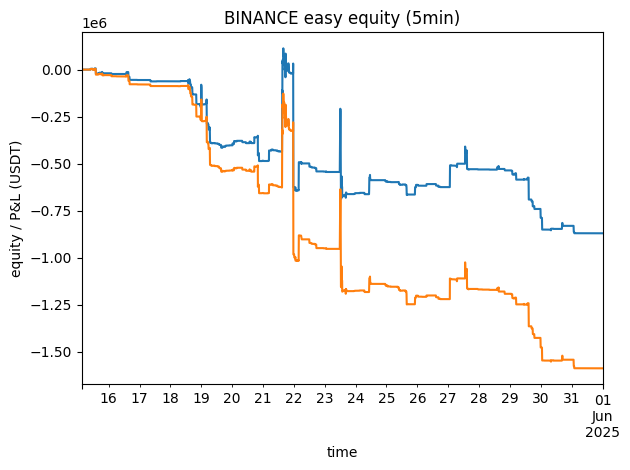

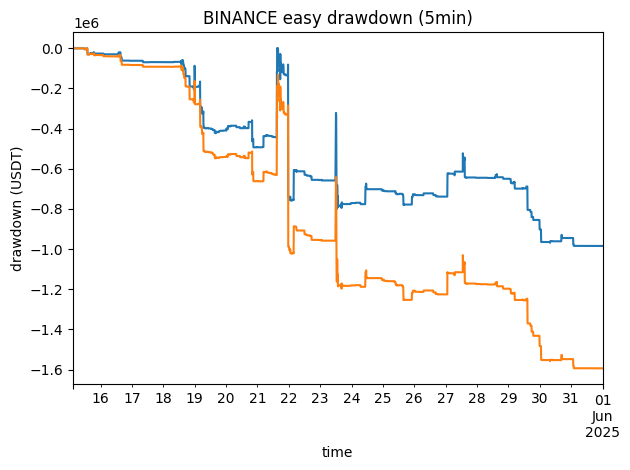

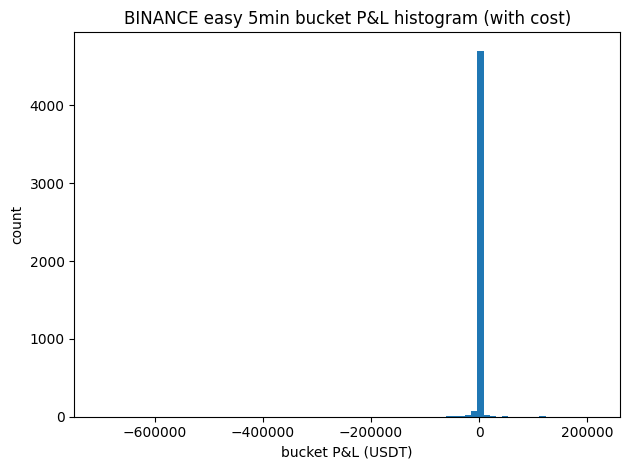

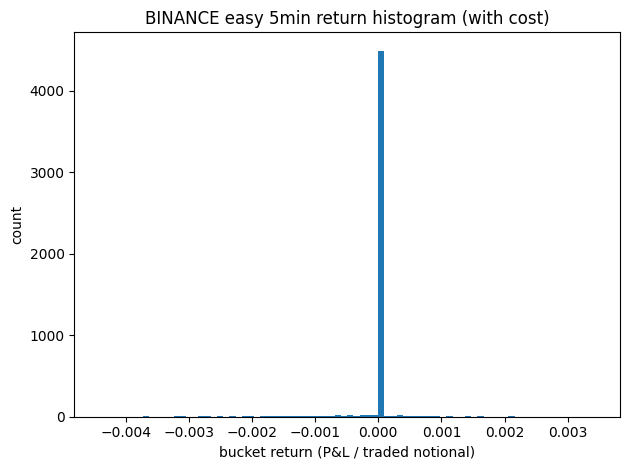

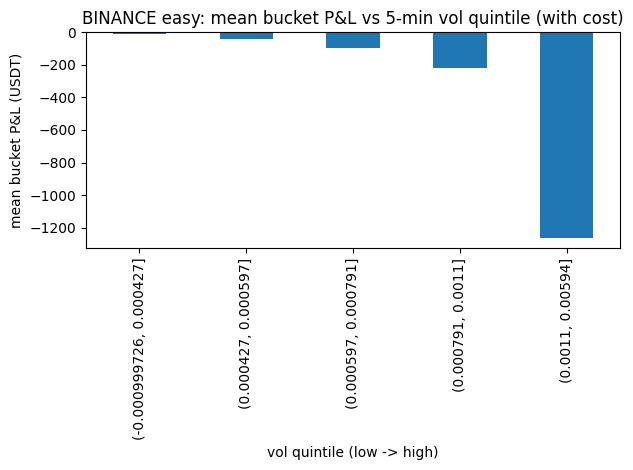

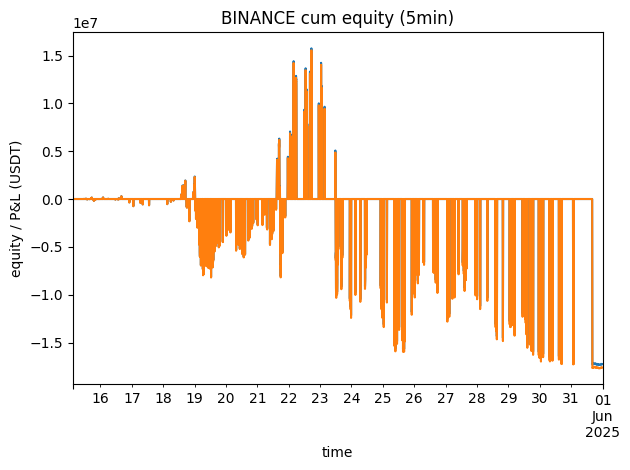

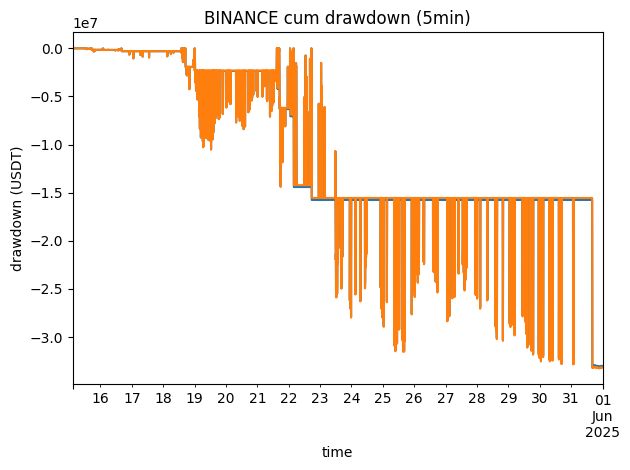

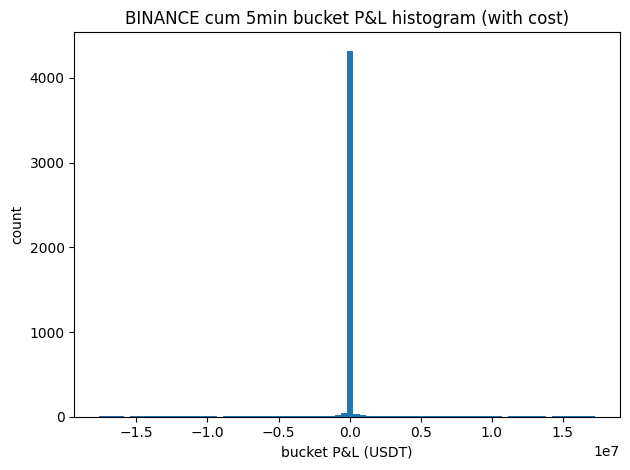

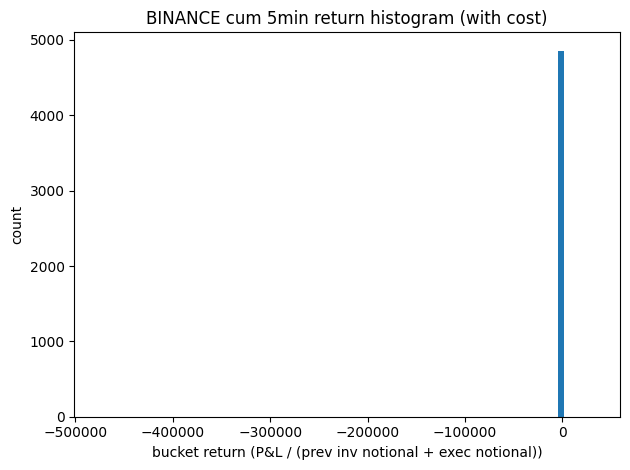

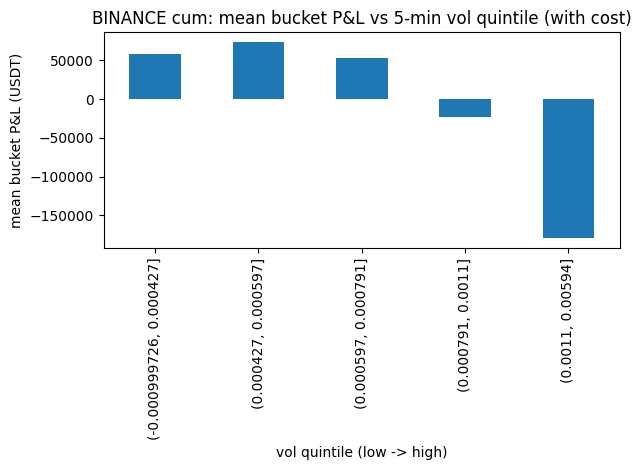

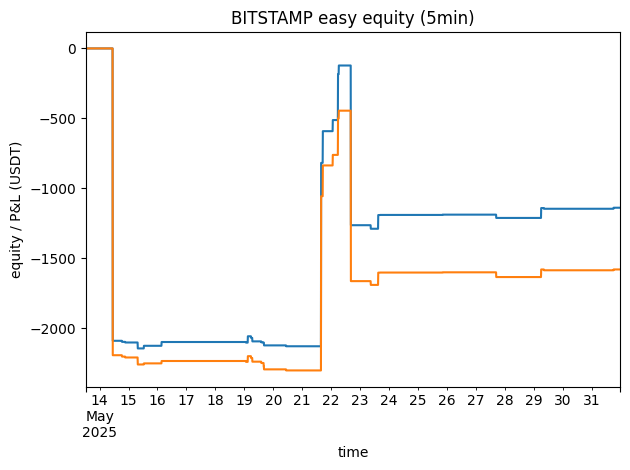

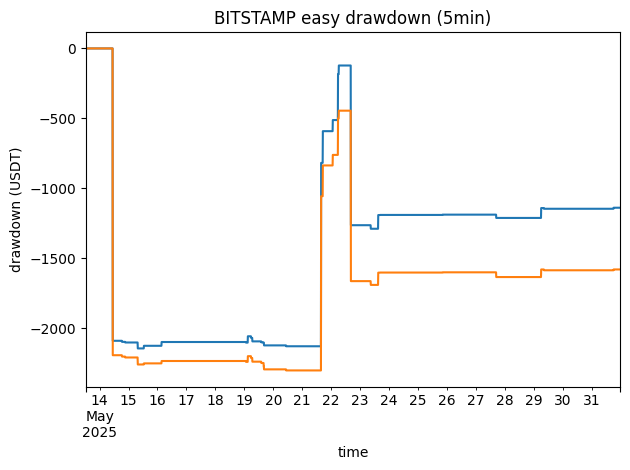

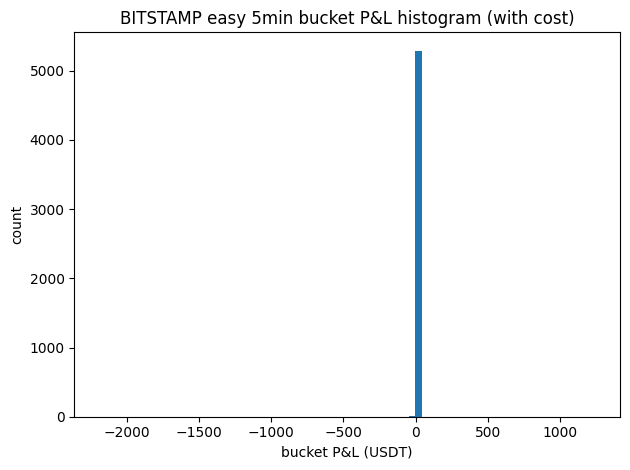

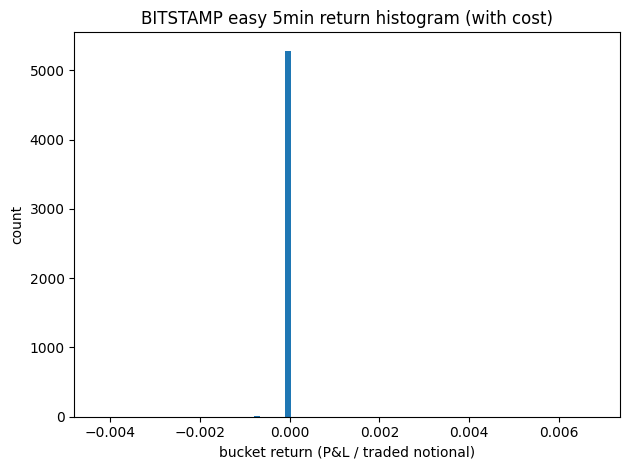

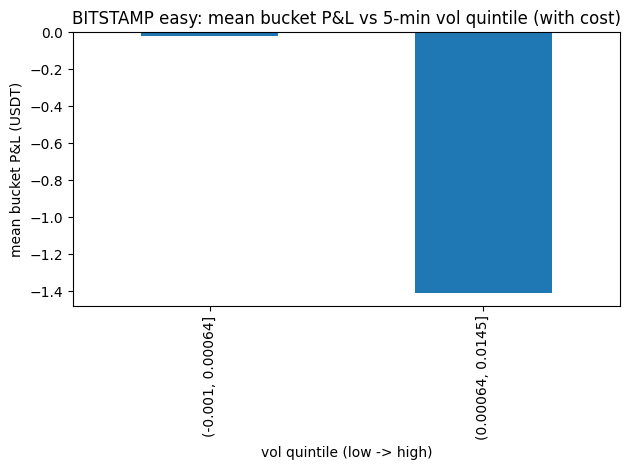

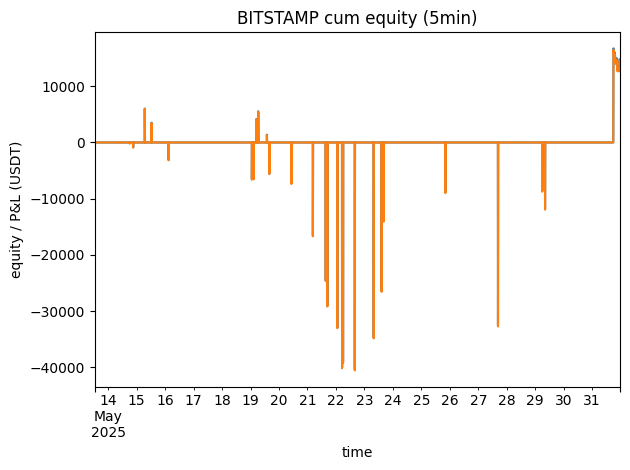

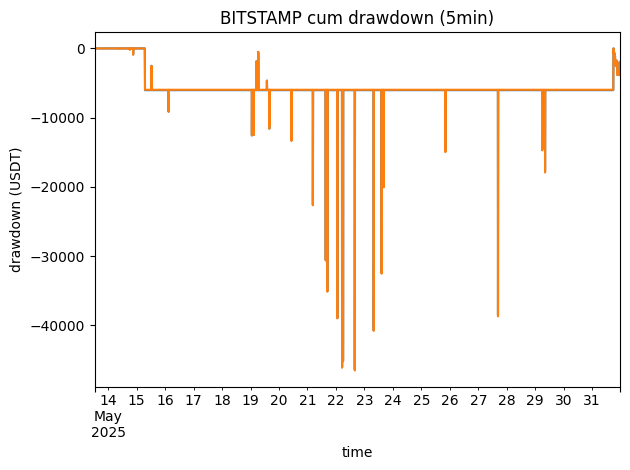

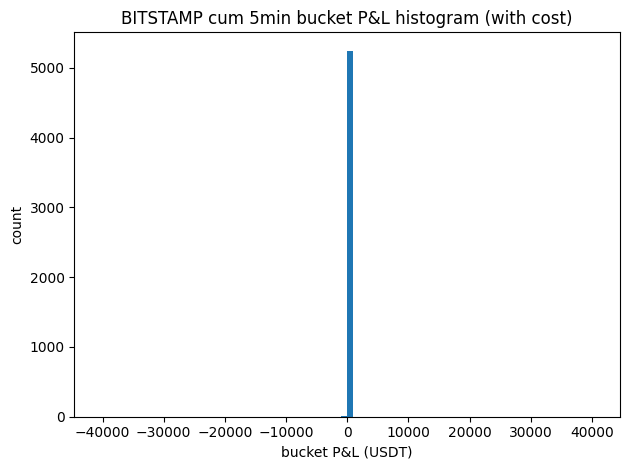

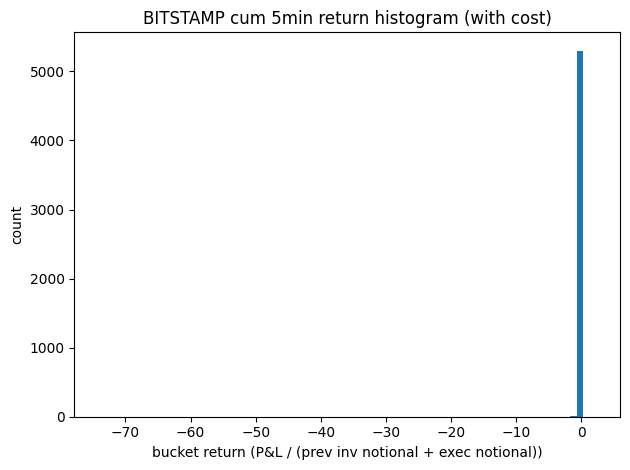

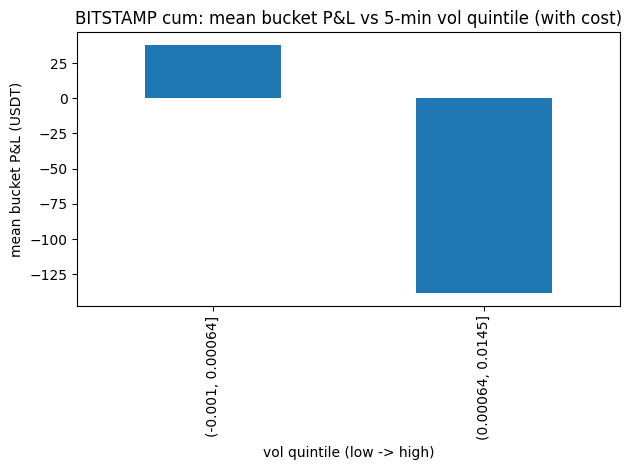

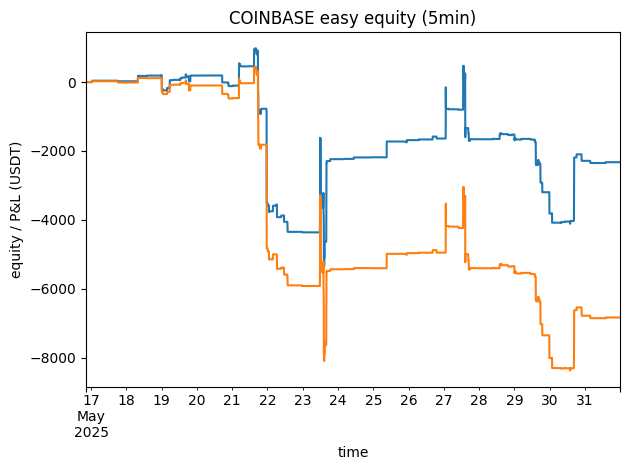

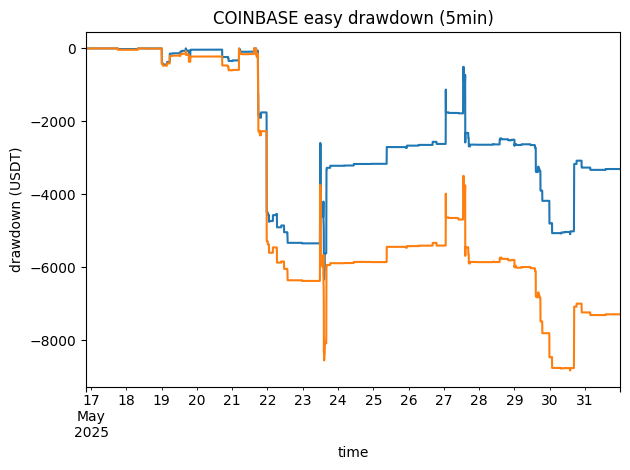

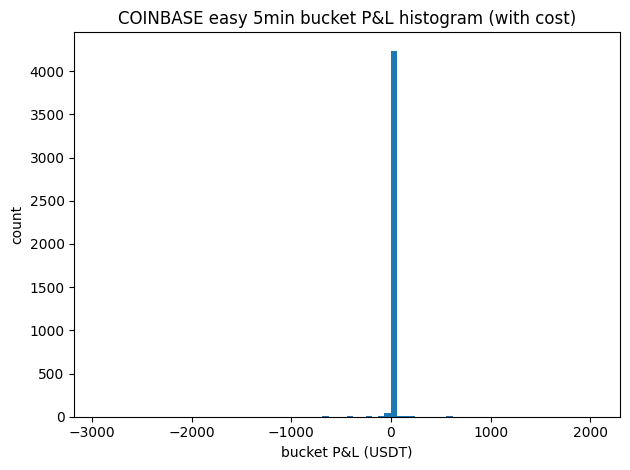

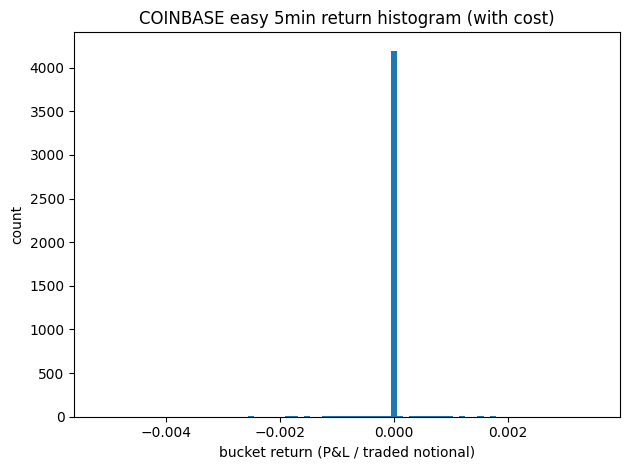

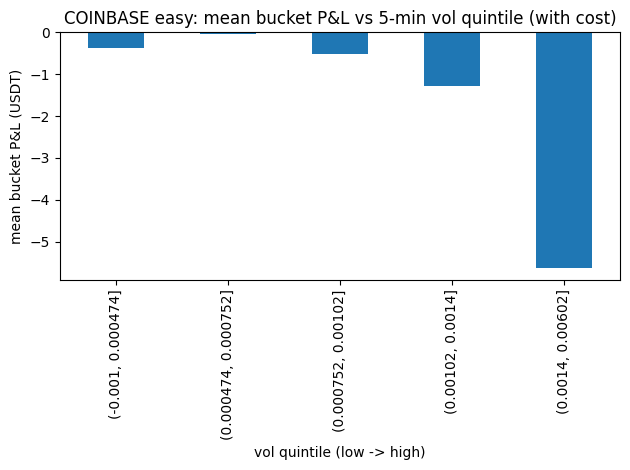

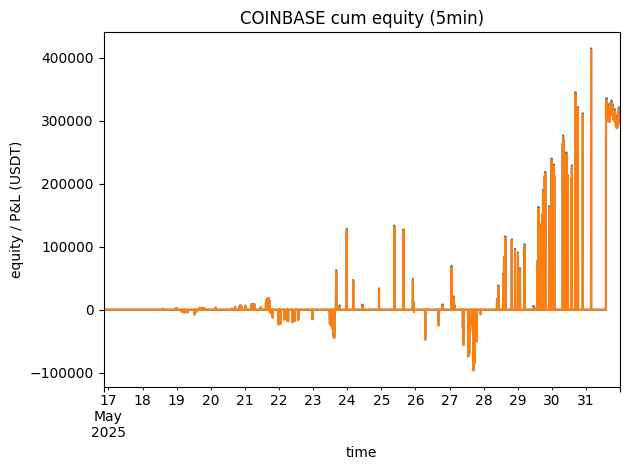

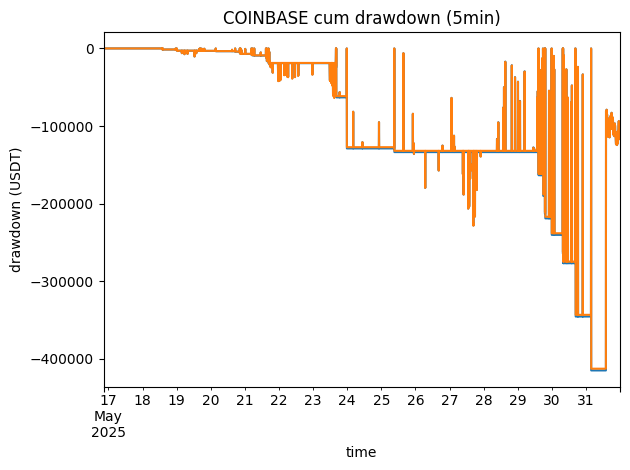

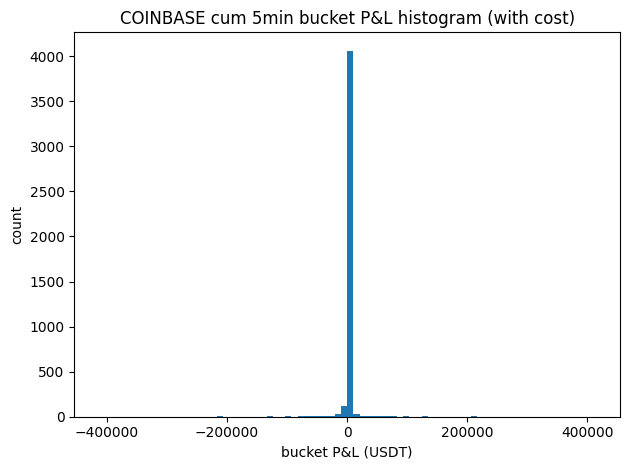

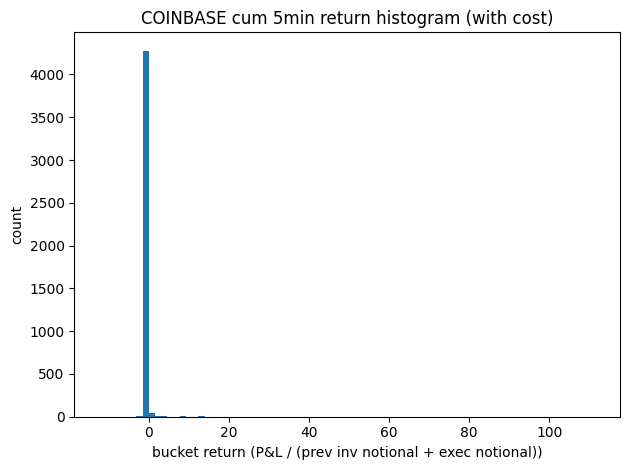

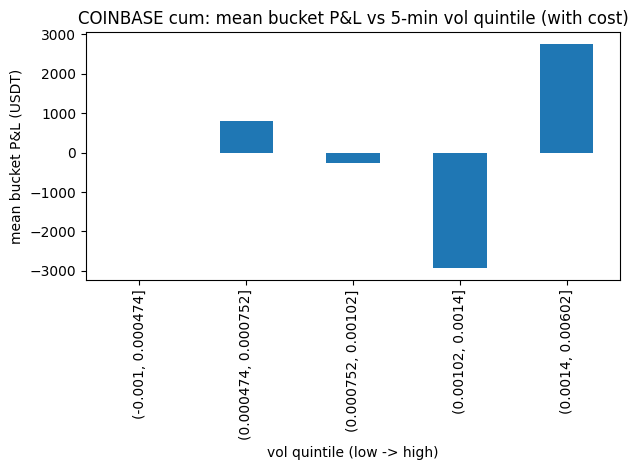

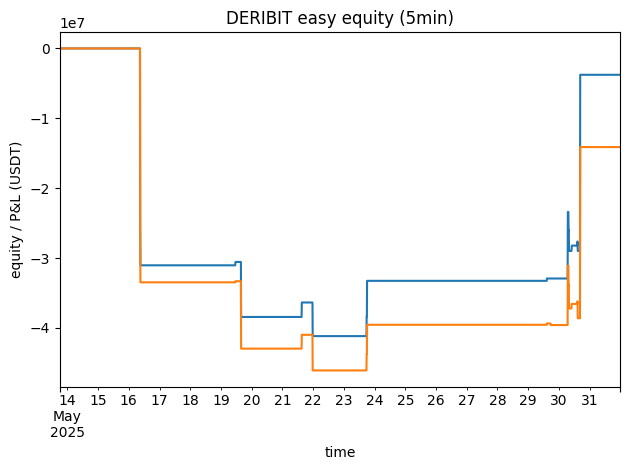

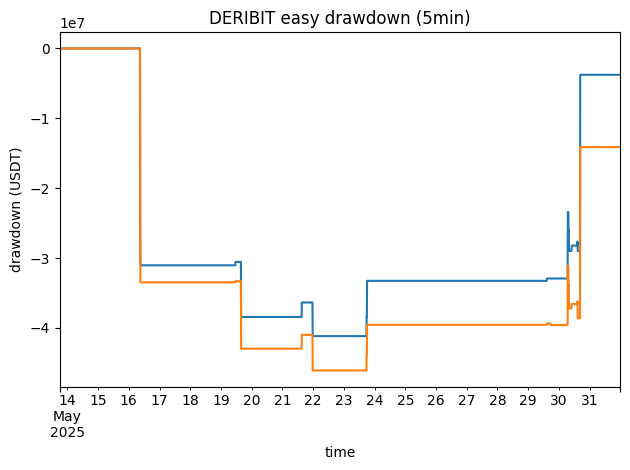

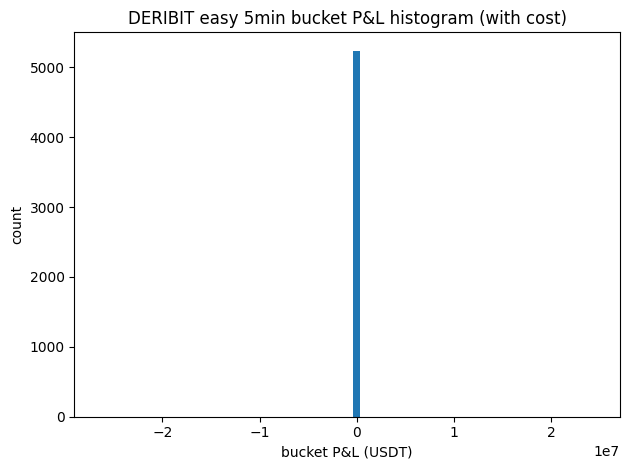

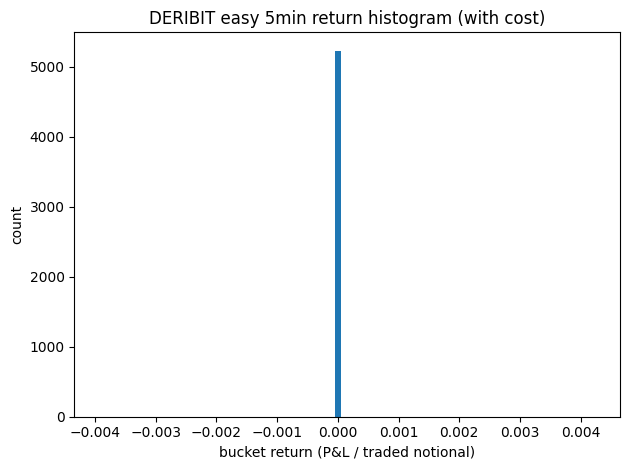

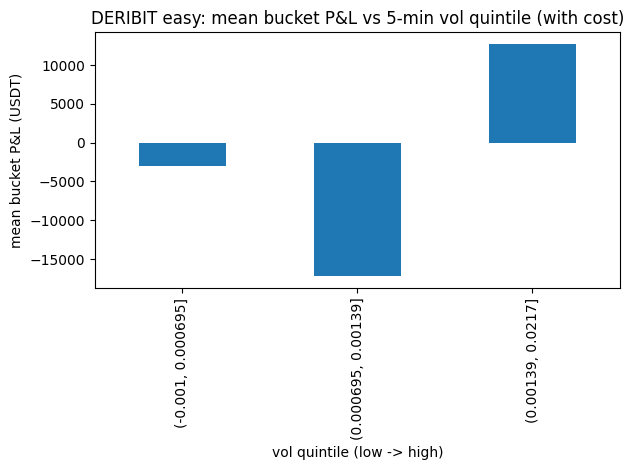

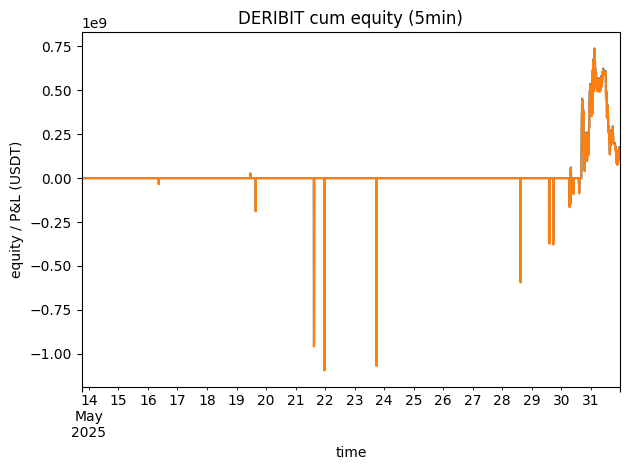

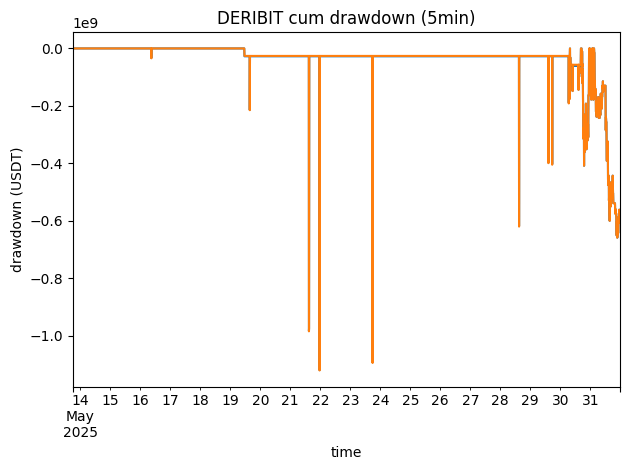

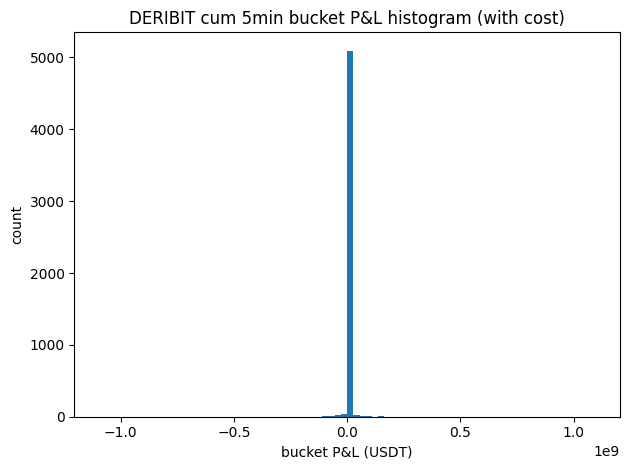

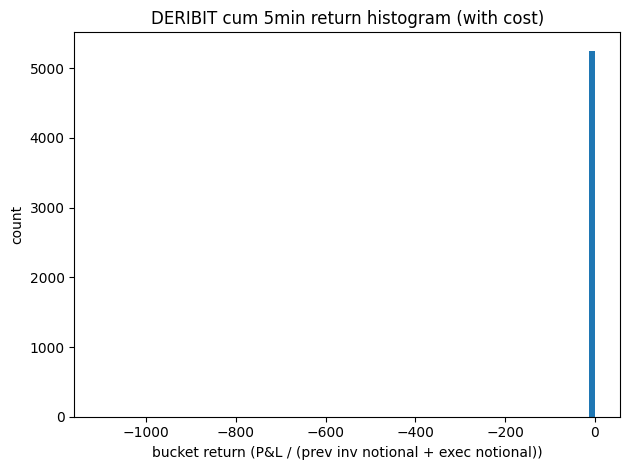

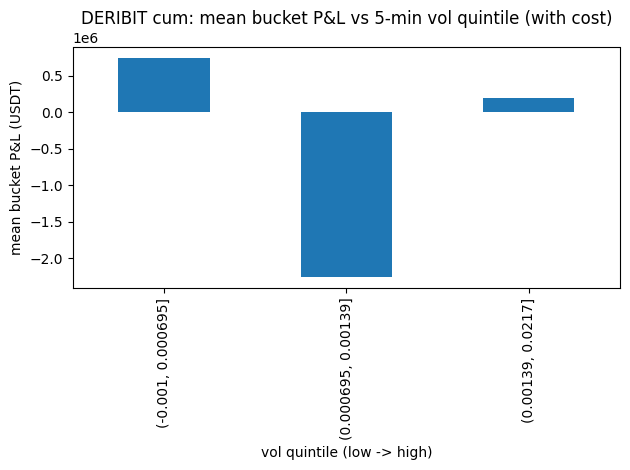

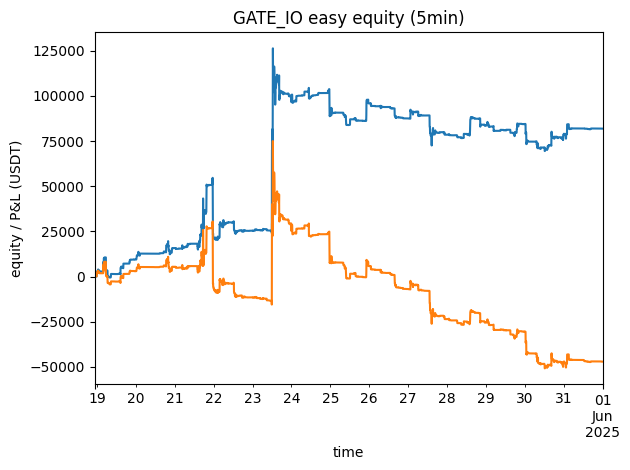

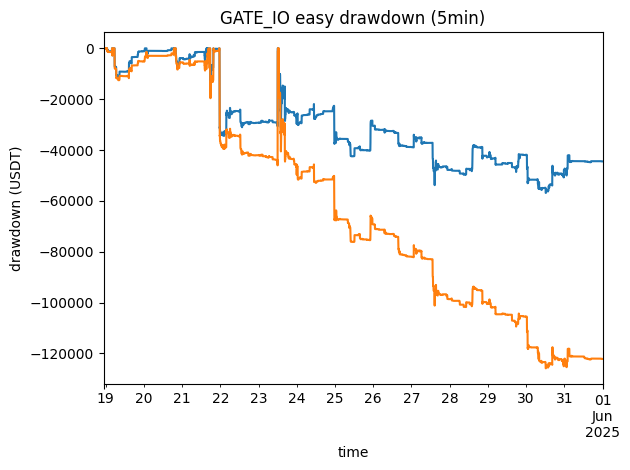

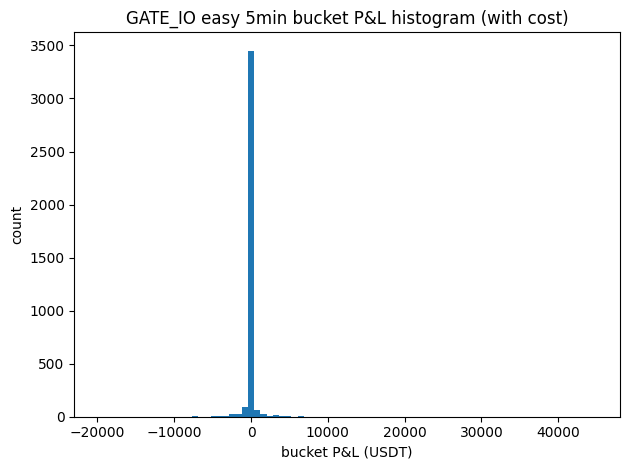

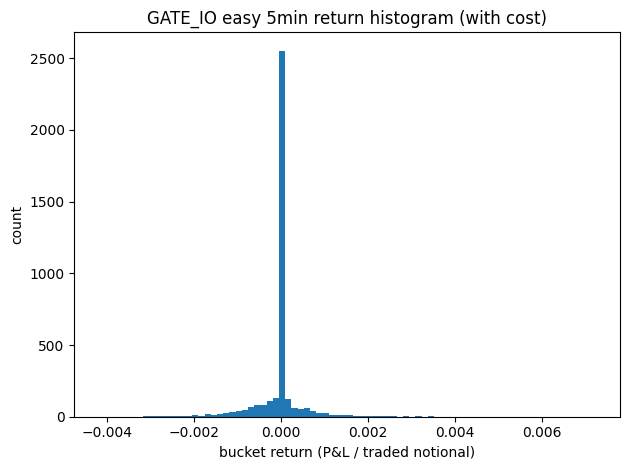

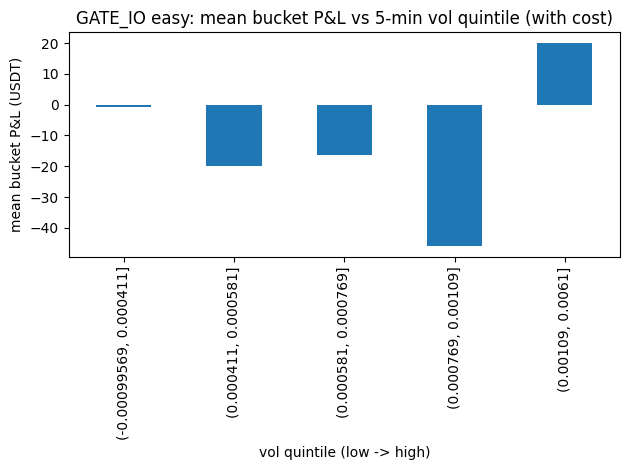

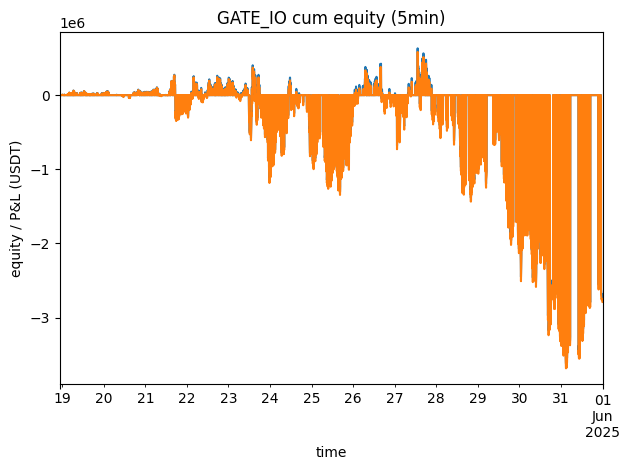

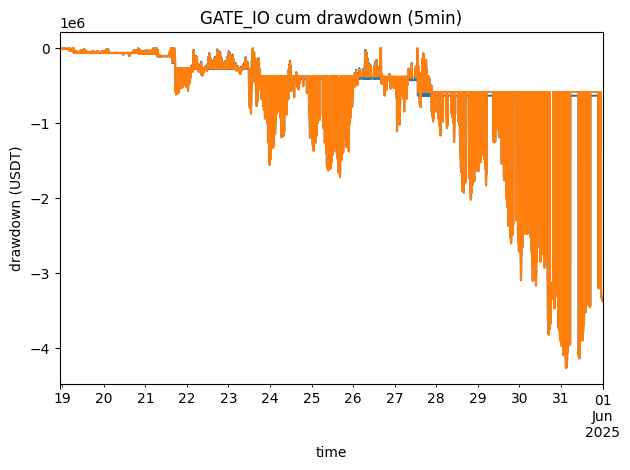

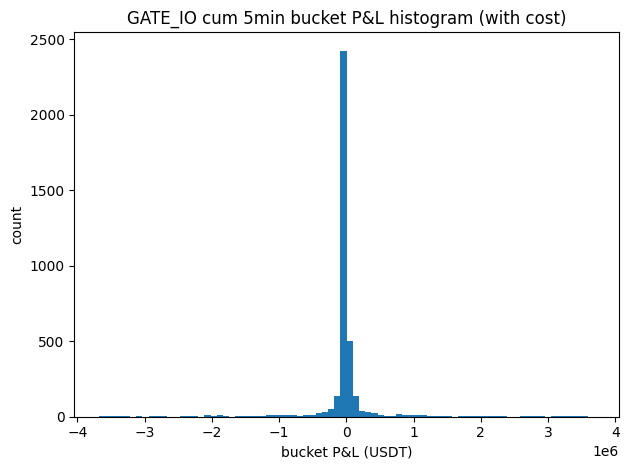

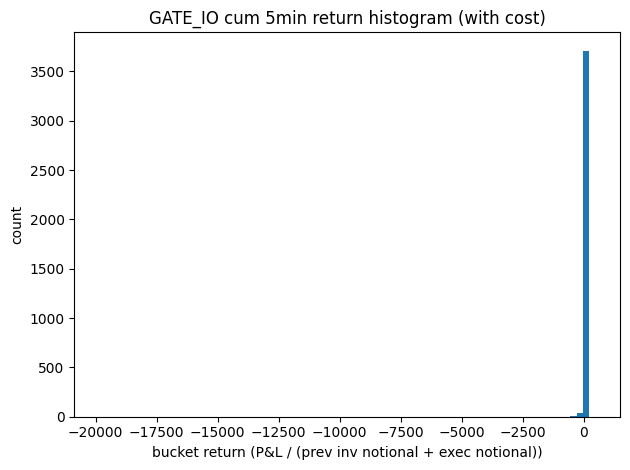

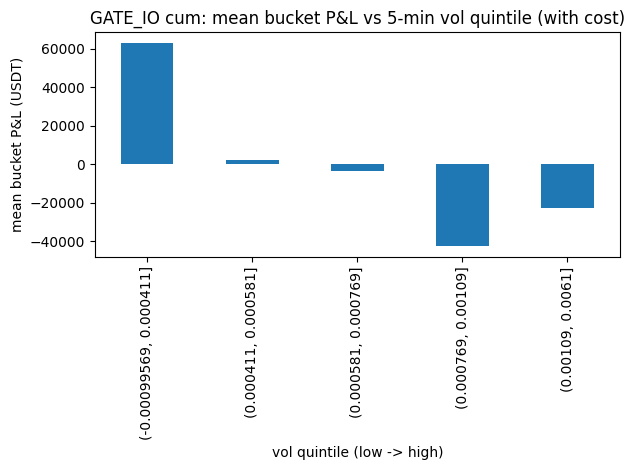

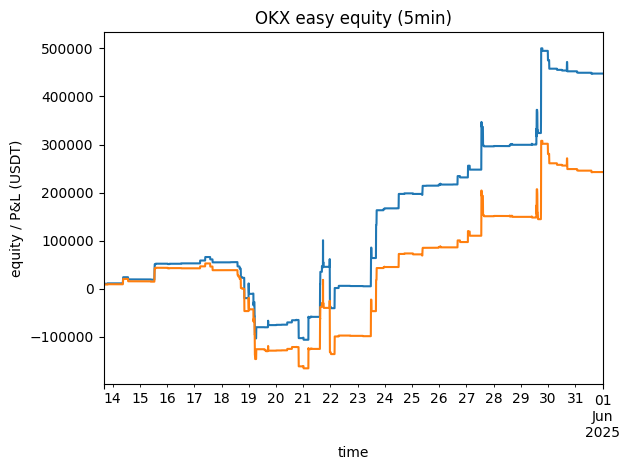

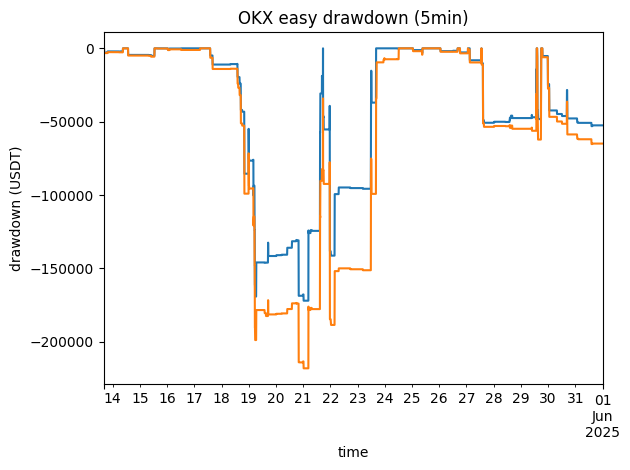

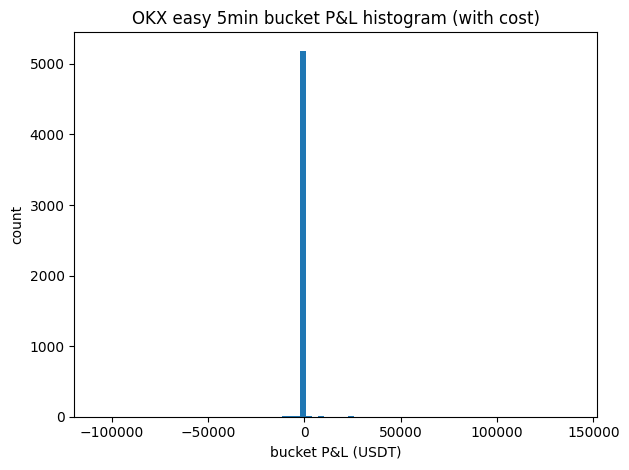

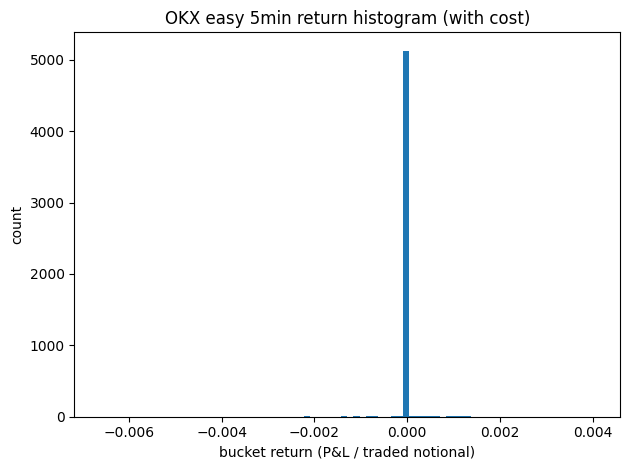

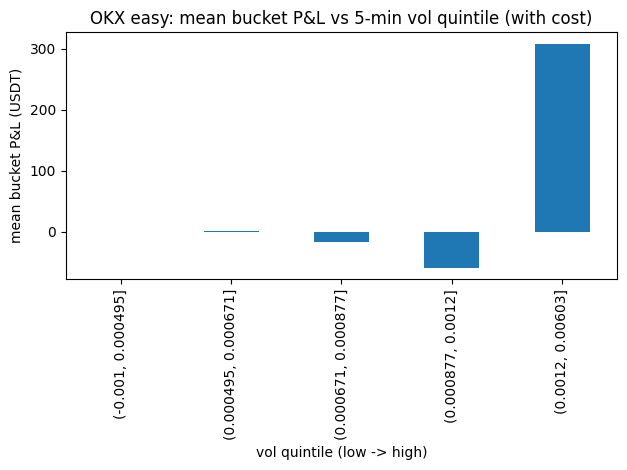

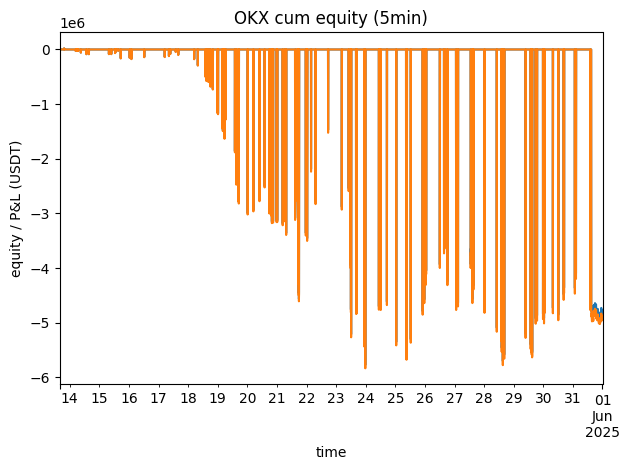

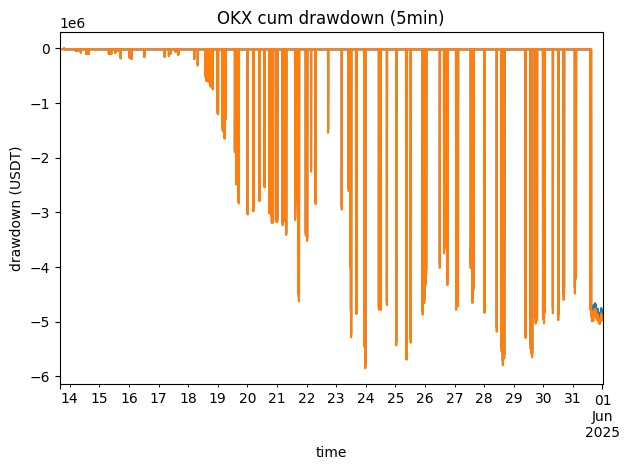

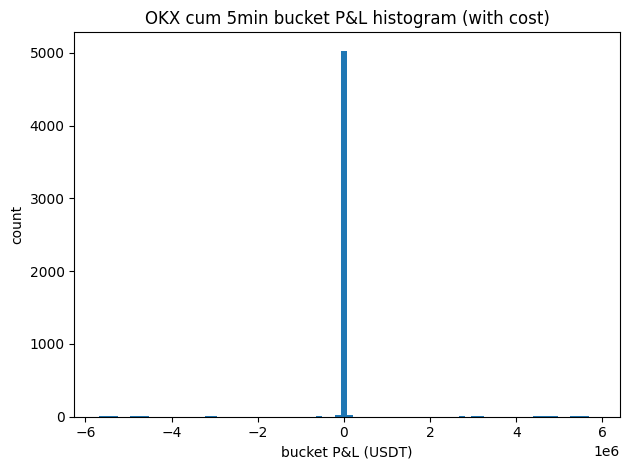

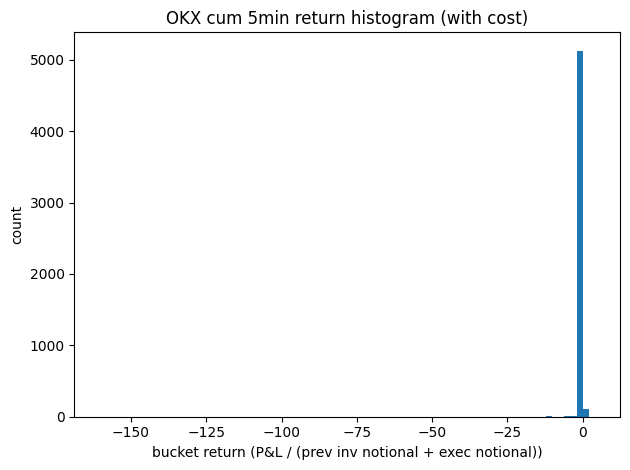

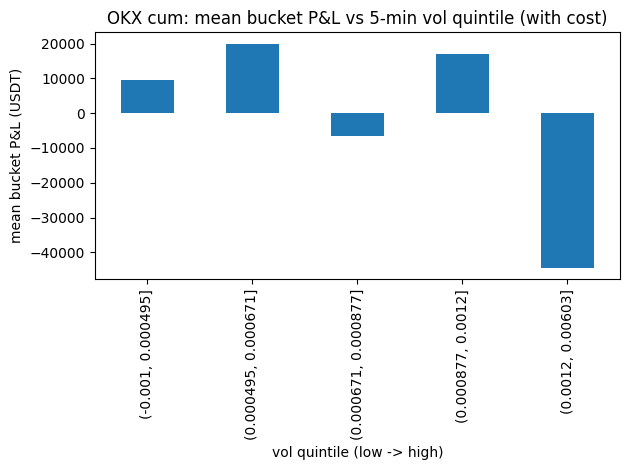

In [10]:
import matplotlib.pyplot as plt
bucket = "5min"

def realized_vol_bucket_from_test_trades(d, bucket="5min", resample_freq="1s"):
    test_mask = (~d["is_train"].astype(bool).values)
    dt = d.loc[test_mask, ["ts", "trade_price"]].copy()
    if len(dt) == 0:
        return pd.Series(dtype=float)
    dt["ts"] = pd.to_datetime(dt["ts"].values.astype("datetime64[ns]"))
    dt = dt.sort_values("ts", kind="mergesort").drop_duplicates("ts").set_index("ts")

    p = dt["trade_price"].astype(float).resample(resample_freq).last().ffill()
    r = np.log(p).diff()
    rv = (r.pow(2).resample(bucket).sum()).pow(0.5)
    return rv

for ex in sorted(exchange_dfs.keys()):
    d = exchange_dfs[ex]
    rv = realized_vol_bucket_from_test_trades(d, bucket=bucket)

    for label in ["easy", "cum"]:
        eq0 = curves[(ex, f"{label}_no_cost")]["equity_bucket"]
        eq1 = curves[(ex, f"{label}_with_cost")]["equity_bucket"]
        dd0 = curves[(ex, f"{label}_no_cost")]["drawdown_bucket"]
        dd1 = curves[(ex, f"{label}_with_cost")]["drawdown_bucket"]

        pnl0 = curves[(ex, f"{label}_no_cost")]["bucket_pnl"]
        pnl1 = curves[(ex, f"{label}_with_cost")]["bucket_pnl"]

        r0  = curves[(ex, f"{label}_no_cost")]["ret_bucket"]
        r1  = curves[(ex, f"{label}_with_cost")]["ret_bucket"]

        plt.figure()
        eq0.plot()
        eq1.plot()
        plt.title(f"{ex} {label} equity ({bucket})")
        plt.xlabel("time")
        plt.ylabel("equity / P&L (USDT)")
        plt.tight_layout()
        plt.show()

        plt.figure()
        dd0.plot()
        dd1.plot()
        plt.title(f"{ex} {label} drawdown ({bucket})")
        plt.xlabel("time")
        plt.ylabel("drawdown (USDT)")
        plt.tight_layout()
        plt.show()

        plt.figure()
        pnl1.plot(kind="hist", bins=80)
        plt.title(f"{ex} {label} {bucket} bucket P&L histogram (with cost)")
        plt.xlabel("bucket P&L (USDT)")
        plt.ylabel("count")
        plt.tight_layout()
        plt.show()

        xlbl = "bucket return (P&L / traded notional)" if label == "easy" else "bucket return (P&L / (prev inv notional + exec notional))"
        plt.figure()
        r1.plot(kind="hist", bins=80)
        plt.title(f"{ex} {label} {bucket} return histogram (with cost)")
        plt.xlabel(xlbl)
        plt.ylabel("count")
        plt.tight_layout()
        plt.show()

        grid = pnl1.index
        rv_g = rv.reindex(grid)
        tmp = pd.DataFrame({"rv_5m": rv_g, "pnl": pnl1}).dropna()

        if len(tmp) > 0:
            tmp["vol_bin"] = pd.qcut(tmp["rv_5m"], 5, duplicates="drop")
            byb = tmp.groupby("vol_bin", observed=True)["pnl"].agg(["mean", "count"])

            plt.figure()
            byb["mean"].plot(kind="bar")
            plt.title(f"{ex} {label}: mean bucket P&L vs 5-min vol quintile (with cost)")
            plt.xlabel("vol quintile (low -> high)")
            plt.ylabel("mean bucket P&L (USDT)")
            plt.tight_layout()
            plt.show()


## Volatility conditioning and Sharpe reporting

Realized volatility is computed on a 5-minute grid and related to bucket P&L/returns. Daily P&L Sharpe is emphasized because the sample length is short and annualized bucket Sharpe can be unstable.

At the 1m/5m baseline with costs, easy-strategy annualized return Sharpe is negative for all exchanges. In the participation sweep, daily Sharpe for the easy strategy is negative for every exchange except OKX at low participation levels (2%, 5%, 10%).


In [11]:
bucket = "5min"

def realized_vol_bucket_from_test_trades(d, bucket="5min", resample_freq="1s"):
    test_mask = (~d["is_train"].astype(bool).values)
    dt = d.loc[test_mask, ["ts", "trade_price"]].copy()
    if len(dt) == 0:
        return pd.Series(dtype=float)
    dt["ts"] = pd.to_datetime(dt["ts"].values.astype("datetime64[ns]"))
    dt = dt.sort_values("ts", kind="mergesort").drop_duplicates("ts").set_index("ts")

    p = dt["trade_price"].astype(float).resample(resample_freq).last().ffill()
    r = np.log(p).diff()
    rv = (r.pow(2).resample(bucket).sum()).pow(0.5)
    return rv

def sharpe(x):
    x = pd.Series(x).dropna()
    if len(x) < 3:
        return np.nan
    sd = x.std(ddof=1)
    if sd == 0 or not np.isfinite(sd):
        return np.nan
    return float(x.mean() / sd)

def annualize_from_daily(sr_daily):
    return np.nan if not np.isfinite(sr_daily) else float(sr_daily * np.sqrt(365.0))

corr_rows = []
bybin_tables = {}
daily_rows = []

for ex in sorted(exchange_dfs.keys()):
    d = exchange_dfs[ex]

    grid = curves[(ex, "easy_with_cost")]["bucket_pnl"].index

    rv = realized_vol_bucket_from_test_trades(d, bucket=bucket).reindex(grid)

    pnl_easy = curves[(ex, "easy_with_cost")]["bucket_pnl"].reindex(grid, fill_value=0.0)
    pnl_cum  = curves[(ex, "cum_with_cost")]["bucket_pnl"].reindex(grid, fill_value=0.0)

    ret_easy = curves[(ex, "easy_with_cost")]["ret_bucket"].reindex(grid, fill_value=0.0)
    traded_easy = curves[(ex, "easy_with_cost")].get("traded_notional_bucket", pd.Series(0.0, index=grid)).reindex(grid, fill_value=0.0)

    df = pd.DataFrame({
        "rv_5m": rv,
        "pnl_easy": pnl_easy,
        "pnl_cum": pnl_cum,
        "ret_easy": ret_easy,
        "traded_easy": traded_easy
    }).dropna(subset=["rv_5m"])

    corr_rows.append({
        "exchange": ex,
        "n_buckets_used": int(len(df)),
        "corr_vol_pnl_easy": float(df["rv_5m"].corr(df["pnl_easy"])) if len(df) > 2 else np.nan,
        "corr_vol_pnl_cum": float(df["rv_5m"].corr(df["pnl_cum"])) if len(df) > 2 else np.nan,
        "corr_vol_ret_easy": float(df["rv_5m"].corr(df["ret_easy"])) if len(df) > 2 else np.nan
    })

    df["active_easy"] = df["traded_easy"] > 0

    if len(df) > 0:
        df["vol_bin"] = pd.qcut(df["rv_5m"], 5, duplicates="drop")
        g = df.groupby("vol_bin", observed=True)

        bybin = g.agg(
            n=("rv_5m", "size"),
            rv_5m_mean=("rv_5m", "mean"),

            pnl_easy_mean=("pnl_easy", "mean"),
            pnl_cum_mean=("pnl_cum", "mean"),
            pnl_easy_std=("pnl_easy", "std"),
            pnl_cum_std=("pnl_cum", "std"),

            ret_easy_mean=("ret_easy", "mean"),
            ret_easy_std=("ret_easy", "std"),
        ).reset_index()

        bybin["sharpe_unannual_pnl_easy"] = g["pnl_easy"].apply(sharpe).values
        bybin["sharpe_unannual_pnl_cum"]  = g["pnl_cum"].apply(sharpe).values

        bybin["sharpe_unannual_ret_easy_all"] = g["ret_easy"].apply(sharpe).values
        bybin["sharpe_unannual_ret_easy_active"] = (
                                df.loc[df["active_easy"]]
                                .groupby("vol_bin", observed=True)["ret_easy"]
                                .apply(sharpe)
                                .reindex(bybin["vol_bin"])
                                .to_numpy()
                            )

    else:
        bybin = pd.DataFrame()

    bybin_tables[ex] = bybin

    pnl_easy_d = pnl_easy.resample("1D").sum()
    pnl_cum_d  = pnl_cum.resample("1D").sum()

    traded_easy_d = traded_easy.resample("1D").sum()
    ret_easy_d = (pnl_easy_d / traded_easy_d).replace([np.inf, -np.inf], np.nan)

    sr_pnl_easy_daily = sharpe(pnl_easy_d)
    sr_pnl_cum_daily  = sharpe(pnl_cum_d)

    sr_ret_easy_daily = sharpe(ret_easy_d.dropna())

    daily_rows.append({
        "exchange": ex,
        "daily_sharpe_pnl_easy": sr_pnl_easy_daily,
        "daily_sharpe_pnl_cum": sr_pnl_cum_daily,
        "daily_sharpe_ret_easy": sr_ret_easy_daily,
        "annualized_from_daily_pnl_easy": annualize_from_daily(sr_pnl_easy_daily),
        "annualized_from_daily_pnl_cum": annualize_from_daily(sr_pnl_cum_daily),
        "annualized_from_daily_ret_easy": annualize_from_daily(sr_ret_easy_daily),
        "n_days_used": int(pnl_easy_d.dropna().shape[0])
    })

vol_corr_summary = pd.DataFrame(corr_rows).sort_values("exchange").reset_index(drop=True)
daily_sharpe_summary = pd.DataFrame(daily_rows).sort_values("exchange").reset_index(drop=True)

vol_corr_summary, daily_sharpe_summary, bybin_tables

(   exchange  n_buckets_used  corr_vol_pnl_easy  corr_vol_pnl_cum  corr_vol_ret_easy
 0   BINANCE            4861          -0.038286         -0.056615          -0.057017
 1  BITSTAMP            5312          -0.019568         -0.031765           0.022619
 2  COINBASE            4359          -0.029623          0.027171          -0.043270
 3   DERIBIT            5252           0.019367         -0.024971           0.006435
 4   GATE_IO            3761           0.041288         -0.035066           0.041089
 5       OKX            5281           0.053715         -0.043080          -0.032902,
    exchange  daily_sharpe_pnl_easy  daily_sharpe_pnl_cum  daily_sharpe_ret_easy  annualized_from_daily_pnl_easy  \
 0   BINANCE              -0.689056             -0.164255              -1.025193                      -13.164389   
 1  BITSTAMP              -0.128030              0.229416              -0.095284                       -2.446015   
 2  COINBASE              -0.319931              0.25000

## Robustness: participation target sweep

Thresholds are recalibrated to target 2%, 5%, 10%, and 20% training participation. The easy round-trip P&L remains negative for BINANCE, BITSTAMP, COINBASE, DERIBIT, and GATE_IO at all targets; OKX is the only exchange with positive easy P&L at 2%, 5%, and 10%, but it turns negative at 20%.

Cumulative P&L is positive for BITSTAMP, COINBASE, and DERIBIT across targets, but those gains coincide with very large inventories (e.g., DERIBIT inventory notional on the order of 1e10), indicating that mark-to-market inventory drift dominates the ledger results. GATE_IO and OKX cumulative P&L remain negative across targets.


In [12]:
bucket = "5min"
cost_bps = 1.0
size_mult = 1.0

targets = [0.02, 0.05, 0.10, 0.20]

def _pick_j_for_target(rhat_train, eligible_train_mask, target):
    x = np.abs(rhat_train[eligible_train_mask])
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    q = 1.0 - float(target)
    q = min(max(q, 0.0), 1.0)
    return float(np.quantile(x, q))

def _test_participation(d, j):
    eligible_test = (~d["is_train"].astype(bool).values) & np.isfinite(d["r_T"].values)
    rhat = d["r_hat"].astype(float).values
    take = eligible_test & (np.abs(rhat) > float(j))
    denom = int(eligible_test.sum())
    return (float(take.sum()) / denom) if denom > 0 else np.nan

def _daily_sharpe_from_bucket_pnl(bucket_pnl):
    pnl_d = bucket_pnl.resample("1D").sum()
    return sharpe(pnl_d)

def _inventory_diagnostics_from_exec_and_prices(d, exs, grid, bucket="5min"):
    if len(grid) == 0:
        return {
            "end_inventory": 0.0,
            "max_abs_inventory": 0.0,
            "avg_abs_inventory": 0.0,
            "avg_inventory_notional": 0.0,
            "max_inventory_notional": 0.0
        }

    if exs is None or len(exs) == 0:
        return {
            "end_inventory": 0.0,
            "max_abs_inventory": 0.0,
            "avg_abs_inventory": 0.0,
            "avg_inventory_notional": 0.0,
            "max_inventory_notional": 0.0
        }

    test_mask = (~d["is_train"].astype(bool).values)
    trades = d.loc[test_mask, ["ts", "trade_price"]].copy()
    if len(trades) == 0:
        return {
            "end_inventory": 0.0,
            "max_abs_inventory": float(np.abs(exs["signed_qty"].astype(float).cumsum()).max()) if "signed_qty" in exs else 0.0,
            "avg_abs_inventory": float(np.abs(exs["signed_qty"].astype(float).cumsum()).mean()) if "signed_qty" in exs else 0.0,
            "avg_inventory_notional": np.nan,
            "max_inventory_notional": np.nan
        }

    trades["ts"] = pd.to_datetime(trades["ts"].values.astype("datetime64[ns]"))
    trades = trades.sort_values("ts", kind="mergesort").drop_duplicates("ts").set_index("ts")
    price_bucket = (
        trades["trade_price"].astype(float)
        .resample(bucket).last()
        .ffill()
        .reindex(grid)
        .ffill()
    )

    exs2 = exs.copy()
    exs2["ts"] = pd.to_datetime(exs2["ts"].values.astype("datetime64[ns]"))
    exs2 = exs2.sort_values("ts", kind="mergesort").set_index("ts")

    inv = exs2["signed_qty"].astype(float).cumsum()
    inv_b = inv.resample(bucket).last().reindex(grid).ffill().fillna(0.0)

    abs_inv = inv_b.abs()
    inv_notional = abs_inv * price_bucket

    return {
        "end_inventory": float(inv.iloc[-1]) if len(inv) else 0.0,
        "max_abs_inventory": float(abs_inv.max()) if len(abs_inv) else 0.0,
        "avg_abs_inventory": float(abs_inv.mean()) if len(abs_inv) else 0.0,
        "avg_inventory_notional": float(inv_notional.mean()) if len(inv_notional) else 0.0,
        "max_inventory_notional": float(inv_notional.max()) if len(inv_notional) else 0.0
    }

rob_rows = []

for ex in sorted(exchange_dfs.keys()):
    d = exchange_dfs[ex]

    eligible_train = (d["is_train"].astype(bool).values) & np.isfinite(d["r_T"].values)
    rhat = d["r_hat"].astype(float).values

    grid = _bucket_grid_from_test(d, bucket=bucket)

    for tgt in targets:
        j_tgt = _pick_j_for_target(rhat, eligible_train, tgt)

        ev = _easy_events_for_exchange(d, j_tgt, size_mult=size_mult)
        exs = _executions_for_exchange(d, j_tgt, size_mult=size_mult)

        easy_wc = easy_roundtrip_bucketed(ev, grid, cost_bps=cost_bps, bucket=bucket)
        cum_wc  = cumulative_inventory_bucketed(d, exs, grid, cost_bps=cost_bps, bucket=bucket)

        test_part = _test_participation(d, j_tgt)

        inv_diag = _inventory_diagnostics_from_exec_and_prices(d, exs, grid, bucket=bucket)

        rob_rows.append({
            "exchange": ex,
            "target_participation_train": tgt,
            "j_threshold": j_tgt,
            "test_participation": test_part,

            "easy_net_pnl": float(easy_wc["net_pnl"]),
            "cum_net_pnl": float(cum_wc["net_pnl"]),

            "daily_sharpe_pnl_easy": _daily_sharpe_from_bucket_pnl(easy_wc["bucket_pnl"]),
            "daily_sharpe_pnl_cum": _daily_sharpe_from_bucket_pnl(cum_wc["bucket_pnl"]),

            "n_events_easy": int(easy_wc["n_events"]),
            "n_exec_cum": int(cum_wc["n_exec"]),

            "cum_end_inventory": inv_diag["end_inventory"],
            "cum_max_abs_inventory": inv_diag["max_abs_inventory"],
            "cum_avg_abs_inventory": inv_diag["avg_abs_inventory"],
            "cum_avg_inventory_notional": inv_diag["avg_inventory_notional"],
            "cum_max_inventory_notional": inv_diag["max_inventory_notional"],
        })

robustness_table = pd.DataFrame(rob_rows).sort_values(
    ["exchange", "target_participation_train"]
).reset_index(drop=True)

robustness_table

,exchange,target_participation_train,j_threshold,test_participation,easy_net_pnl,cum_net_pnl,daily_sharpe_pnl_easy,daily_sharpe_pnl_cum,n_events_easy,n_exec_cum,cum_end_inventory,cum_max_abs_inventory,cum_avg_abs_inventory,cum_avg_inventory_notional,cum_max_inventory_notional
0,BINANCE,0.02,0.000143,0.015086,-1.059593e+06,-1.866235e+07,-0.513297,-0.235584,985285,985285,2776.914165,5162.800795,2508.995510,2.714943e+08,5.774680e+08
1,BINANCE,0.05,0.000077,0.044909,-1.589599e+06,-1.761641e+07,-0.689121,-0.164284,2933003,2933003,-320.062875,7017.944855,2180.224904,2.366728e+08,7.824233e+08
2,BINANCE,0.10,0.000043,0.100826,-2.353590e+06,-1.302487e+07,-1.038380,-0.107355,6584897,6584897,-4716.194295,7851.532575,2335.739768,2.514667e+08,8.743950e+08
3,BINANCE,0.20,0.000023,0.215752,-3.306759e+06,-7.883353e+06,-1.105092,-0.041228,14090627,14090627,-12487.194815,12669.490105,3669.729927,3.925551e+08,1.315028e+09
4,BITSTAMP,0.02,0.000822,0.024538,-1.693526e+03,7.272245e+03,-0.143970,0.128925,101,101,-7.678550,8.106263,6.309199,6.743875e+05,8.955394e+05
5,BITSTAMP,0.05,0.000345,0.042031,-1.588615e+03,1.404055e+04,-0.128759,0.229416,173,173,-7.826551,8.583759,6.332760,6.772745e+05,9.556556e+05
6,BITSTAMP,0.10,0.000078,0.149903,-1.646228e+03,9.898962e+03,-0.126174,0.229416,617,617,-7.456962,11.098772,7.861936,8.414352e+05,1.235326e+06
7,BITSTAMP,0.20,0.000013,0.285228,-1.295603e+03,1.676776e+04,-0.087147,0.229416,1174,1174,-7.856789,11.607225,8.007068,8.577139e+05,1.297289e+06
8,COINBASE,0.02,0.000326,0.015995,-2.447075e+03,6.004703e+04,-0.194216,0.202154,4357,4357,-18.448713,19.315105,9.459635,1.017464e+06,2.013410e+06
9,COINBASE,0.05,0.000176,0.057359,-6.852256e+03,3.070027e+05,-0.320071,0.250000,15624,15624,-79.543812,81.707543,39.273462,4.219021e+06,8.656001e+06


## Conclusion

- The required pipeline is implemented end-to-end: flow signal -> forward return regression -> thresholded trading -> two P&L methods -> costs, drawdowns, and volatility conditioning.
- With the professor-recommended $\tau=1$ minute and $T=5$ minutes, easy round-trip P&L with costs is negative for five of six exchanges; OKX is positive but still has negative return Sharpe.
- Cumulative P&L is positive on BITSTAMP, COINBASE, and DERIBIT but is accompanied by large inventories and deep drawdowns, making it a weak proxy for a tradable edge.
- Split-sample $\beta$ instability and participation sensitivity indicate a fragile signal; a rolling fit and explicit inventory limits are necessary before any trading claim is credible.


## Deeper results analysis

**Baseline (1m/5m, professor-recommended).** Easy round-trip P&L with costs is negative on BINANCE, BITSTAMP, COINBASE, DERIBIT, and GATE_IO. OKX is positive in dollar terms but shows a negative return Sharpe, so the gain is not stable. Cumulative P&L is positive on BITSTAMP, COINBASE, and DERIBIT but coincides with large inventory exposure and extreme drawdowns, indicating inventory drift rather than clean predictive power.

**Signal stability.** Timing checks are clean, but $\beta$ is unstable: sign flips occur for all exchanges except COINBASE, and magnitude swings are large (ratio up to 9.21). This supports a regime-dependent relationship that is unlikely to persist out of sample without frequent refits.

**Participation sensitivity.** Increasing participation generally worsens easy P&L. OKX is the only exchange with positive easy P&L at low participation, and even there the daily Sharpe is modest.

**Horizon sensitivity (5% participation).** Shorter horizons (10s/60s and 30s/120s) still show negative easy P&L across most exchanges. At 120s/600s, BINANCE shows positive easy and cumulative P&L with positive return Sharpe; COINBASE shows a small positive easy P&L but negative Sharpe. These isolated positives do not overturn the overall pattern of weak and unstable performance and should be treated as exploratory rather than robust.


In [13]:
pairs = [
    (10, 60),   # 10s -> 1m
    (30, 120),  # 30s -> 2m
    (60, 300),  # 1m  -> 5m
    (120, 600), # 2m  -> 10m
]

target_participation = 0.05

if "df_raw" in globals():
    df_base = df_raw
else:
    df_base = df

if not ("Exchange" in df_base.columns or "exchange" in df_base.columns):
    try:
        df_base = pd.read_parquet(data_path, engine="pyarrow")
    except Exception as e:
        raise ValueError("Exchange column not found in df; reload the parquet cell or set df_raw = original trades df") from e

ex_col = "Exchange" if "Exchange" in df_base.columns else "exchange"
exchanges = sorted(df_base[ex_col].dropna().unique().tolist())

sweep_rows = []

for tau_s, T_s in pairs:
    exchange_dfs_local = {}
    j_map_local = {}

    for ex in exchanges:
        d = prepare_exchange_df(df_base, ex, ex_col=ex_col)

        n = len(d)
        cut = int(n * 0.4)
        d["is_train"] = np.arange(n, dtype=np.int64) < cut

        d = compute_flow_and_return(d, tau_s=tau_s, T_s=T_s)
        d, beta, j, valid_train = fit_beta_and_threshold(d, target_participation=target_participation)
        exchange_dfs_local[ex] = d
        j_map_local[ex] = j

    easy_rows = []
    cum_rows = []

    for ex_name, d in exchange_dfs_local.items():
        j = float(j_map_local[ex_name])
        grid = _bucket_grid_from_test(d, bucket=bucket)

        ev = _easy_events_for_exchange(d, j, size_mult=size_mult)
        exs = _executions_for_exchange(d, j, size_mult=size_mult)

        easy1 = easy_roundtrip_bucketed(ev, grid, cost_bps=cost_bps, bucket=bucket)
        cum1  = cumulative_inventory_bucketed(d, exs, grid, cost_bps=cost_bps, bucket=bucket)

        easy_rows.append({
            "exchange": ex_name,
            "easy_net_pnl_with_cost": easy1["net_pnl"],
            "easy_sharpe_annual_ret_with_cost": sharpe_annual_from_series(easy1["ret_bucket"], bucket),
        })
        cum_rows.append({
            "exchange": ex_name,
            "cum_net_pnl_with_cost": cum1["net_pnl"],
            "cum_sharpe_annual_ret_with_cost": sharpe_annual_from_series(cum1["ret_bucket"], bucket),
        })

    easy_df = pd.DataFrame(easy_rows)
    cum_df = pd.DataFrame(cum_rows)
    merged = easy_df.merge(cum_df, on="exchange")
    merged["tau_s"] = tau_s
    merged["T_s"] = T_s
    sweep_rows.append(merged)

sweep_results = pd.concat(sweep_rows, ignore_index=True)
sweep_results



,exchange,easy_net_pnl_with_cost,easy_sharpe_annual_ret_with_cost,cum_net_pnl_with_cost,cum_sharpe_annual_ret_with_cost,tau_s,T_s
0,BINANCE,-7.041127e+05,-66.775013,-1.527580e+07,-5.876811,10,60
1,BITSTAMP,-3.249628e+02,-0.192411,1.291675e+04,-1.506494,10,60
2,COINBASE,-2.419980e+03,-3.722637,-9.217992e+04,-9.406961,10,60
3,DERIBIT,-1.832481e+07,-7.443965,2.943962e+08,-7.794564,10,60
4,GATE_IO,-1.232848e+05,-103.151891,9.716344e+05,12.307879,10,60
5,OKX,-4.757422e+05,-9.109186,7.225398e+06,2.772557,10,60
6,BINANCE,-4.249121e+05,-39.488123,-1.707882e+07,-5.325800,30,120
7,BITSTAMP,-3.483672e+02,3.203077,1.320606e+04,-5.390704,30,120
8,COINBASE,-2.588535e+03,-15.918311,1.771007e+05,18.996211,30,120
9,DERIBIT,-2.304276e+07,-5.777768,2.571025e+08,-8.805029,30,120


## Market and economic considerations

- **Microstructure regime**: Trade-flow effects are strongest at very short horizons; at 1m/5m they can be diluted by broader order-flow and inventory dynamics.
- **Fee tiers and rebates**: Venue-specific fee schedules can flip the sign of a marginal edge; a realistic analysis would condition on maker/taker mix and fee tiers.
- **Market impact and slippage**: Execution is assumed at printed prices; real fills would incur slippage, especially during high-volatility regimes.
- **Liquidity and queue position**: Execution quality depends on queue priority and cancellation behavior, which are not modeled here.
- **Risk budgeting**: Inventory limits and volatility scaling are required; the cumulative ledger results are dominated by inventory drift on several exchanges.
- **Economic interpretation**: If any edge exists, it likely reflects short-lived order-flow pressure and is sensitive to participant composition and latency advantages.
